# A) Baseline pipeline
### efficientnet_b0
### resnet50
### mobilenet_v2

**Cell 1 — Imports, global config, silence warnings**

In [3]:
# Core imports + quiet mode
import os, json, random
from pathlib import Path
from typing import List, Dict

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, efficientnet_b0
from torchvision.models import ResNet50_Weights, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
    precision_recall_curve, auc
)
from scipy.stats import pearsonr

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Paths (adjust if needed)
IMAGES_DIR = "/kaggle/input/dataset/Dataset/Dataset/images"
ANN_DIR    = "/kaggle/input/dataset/Dataset/Dataset/annotations"
OUT_ROOT   = "/kaggle/working/affect_runs"

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)


**Cell 2 — Helper I/O utilities**

In [4]:
# Image id listing + annotation presence check
def list_image_ids(images_dir: str) -> List[str]:
    exts = ("*.jpg", "*.jpeg", "*.png")
    paths = []
    for e in exts:
        paths.extend(Path(images_dir).glob(e))
    return sorted({p.stem for p in paths})

def has_all_annotations(ann_dir: str, image_id: str) -> bool:
    return all((Path(ann_dir) / f"{image_id}_{suf}.npy").exists()
               for suf in ["exp", "val", "aro"])


**Cell 3 — Dataset**

In [5]:
class AffectDataset(Dataset):
    CLASSES = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]
    NUM_CLASSES = 8

    def __init__(self, ids: List[str], images_dir: str, ann_dir: str, transform=None):
        self.ids = ids
        self.images_dir = images_dir
        self.ann_dir = ann_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # locate image file (jpg/jpeg/png)
        img_path = None
        for ext in (".jpg",".jpeg",".png"):
            p = Path(self.images_dir) / f"{img_id}{ext}"
            if p.exists():
                img_path = p
                break
        if img_path is None:
            raise FileNotFoundError(f"Image not found for id {img_id}")

        # load to PIL for transforms
        t = torchvision.io.read_image(str(img_path)).float() / 255.0  # (C,H,W)
        t = t[:3] if t.shape[0] >= 3 else t.expand(3, *t.shape[1:])
        pil = torchvision.transforms.functional.to_pil_image((t*255).to(torch.uint8))

        img = self.transform(pil) if self.transform is not None else transforms.ToTensor()(pil)

        # annotations (exp: int, val/aro: float; -2 means missing)
        exp = int(np.load(Path(self.ann_dir)/f"{img_id}_exp.npy").astype(np.int64).item())
        val = np.load(Path(self.ann_dir)/f"{img_id}_val.npy").astype(np.float32).item()
        aro = np.load(Path(self.ann_dir)/f"{img_id}_aro.npy").astype(np.float32).item()

        return {
            "image": img,
            "exp": np.int64(exp),
            "val": np.float32(val),
            "aro": np.float32(aro),
            "id": img_id,
        }


**Cell 4 — Transforms**

In [6]:
def build_transforms(img_size: int = 224):
    train_tfms = transforms.Compose([
        transforms.Resize(int(img_size*1.1)),
        transforms.RandomResizedCrop(img_size, scale=(0.8,1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize(int(img_size*1.1)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return train_tfms, val_tfms


**Cell 5 — Model (robust pretrained fallback)**

In [7]:
class MultiTaskNet(nn.Module):
    def __init__(self, arch: str = "resnet50", pretrained: bool = True, dropout: float = 0.2):
        super().__init__()
        self.arch = arch

        def _try_make(maker, weights):
            try:
                return maker(weights=weights), True
            except Exception as e:
                print(f"[WARN] Could not load pretrained weights for {arch}: {e}\n"
                      f"       Falling back to random init.")
                return maker(weights=None), False

        if arch == "resnet50":
            model, _ = _try_make(resnet50, ResNet50_Weights.DEFAULT if pretrained else None)
            feat_dim = model.fc.in_features
            model.fc = nn.Identity()
            self.backbone = model

        elif arch == "efficientnet_b0":
            model, _ = _try_make(efficientnet_b0, EfficientNet_B0_Weights.DEFAULT if pretrained else None)
            feat_dim = model.classifier[1].in_features
            model.classifier[-1] = nn.Identity()
            self.backbone = model

        elif arch == "mobilenet_v2":
            maker = torchvision.models.mobilenet_v2
            weights = torchvision.models.MobileNet_V2_Weights.DEFAULT if pretrained else None
            model, _ = _try_make(maker, weights)
            feat_dim = model.classifier[-1].in_features
            model.classifier[-1] = nn.Identity()
            self.backbone = model

        else:
            raise ValueError(f"Unknown arch: {arch}")

        self.dropout = nn.Dropout(p=dropout)
        self.exp_head = nn.Linear(feat_dim, 8)
        self.reg_head = nn.Linear(feat_dim, 2)  # (valence, arousal)

    def forward(self, x):
        feats = self.backbone(x)
        feats = self.dropout(feats)
        exp_logits = self.exp_head(feats)
        reg_out = torch.tanh(self.reg_head(feats))  # clamp to [-1,1]
        return exp_logits, reg_out


**Cell 6 — Metrics**

In [8]:
def krippendorff_alpha_nominal(two_raters_labels: np.ndarray) -> float:
    labels = np.unique(two_raters_labels.flatten())
    n_cat = len(labels)
    label_to_idx = {l:i for i,l in enumerate(labels)}
    coincidence = np.zeros((n_cat, n_cat), dtype=np.float64)
    for a,b in two_raters_labels.T:
        ia = label_to_idx[a]; ib = label_to_idx[b]
        coincidence[ia, ib] += 1
        coincidence[ib, ia] += 1
    Do = np.sum(coincidence * (1 - np.eye(n_cat)))
    m = coincidence.sum(axis=0); n_tot = m.sum()
    De = np.sum(np.outer(m, m) * (1 - np.eye(n_cat))) / max(n_tot-1, 1)
    if De == 0: return 1.0
    return float(1 - Do/De)

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    mask = (y_true != -2)
    y_t = y_true[mask]; y_p = y_pred[mask]
    if len(y_t) == 0:
        return {"rmse": np.nan, "corr": np.nan, "sagr": np.nan, "ccc": np.nan}
    rmse = float(np.sqrt(np.mean((y_p - y_t) ** 2)))
    try: corr = float(pearsonr(y_t, y_p)[0])
    except Exception: corr = np.nan
    sagr = float(np.mean(np.sign(y_t) == np.sign(y_p)))
    mu_t, mu_p = np.mean(y_t), np.mean(y_p)
    var_t, var_p = np.var(y_t), np.var(y_p)
    cov = float(np.mean((y_t - mu_t) * (y_p - mu_p)))
    ccc = (2 * cov) / (var_t + var_p + (mu_t - mu_p) ** 2 + 1e-12)
    return {"rmse": rmse, "corr": corr, "sagr": sagr, "ccc": float(ccc)}

def classification_metrics(y_true: np.ndarray, logits: np.ndarray) -> Dict[str, float]:
    y_pred = logits.argmax(axis=1)
    acc = float(accuracy_score(y_true, y_pred))
    f1  = float(f1_score(y_true, y_pred, average="macro"))
    kappa = float(cohen_kappa_score(y_true, y_pred))
    try:
        alpha = float(krippendorff_alpha_nominal(np.vstack([y_true, y_pred])))
    except Exception:
        alpha = float("nan")
    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    try:
        roc_macro = float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro"))
    except Exception:
        roc_macro = float("nan")
    pr_aucs = []
    for c in range(probs.shape[1]):
        y_bin = (y_true == c).astype(int)
        precision, recall, _ = precision_recall_curve(y_bin, probs[:, c])
        pr_aucs.append(auc(recall, precision))
    pr_macro = float(np.mean(pr_aucs)) if pr_aucs else float("nan")
    return {"acc": acc, "f1_macro": f1, "kappa": kappa,
            "alpha": alpha, "roc_auc_macro": roc_macro, "pr_auc_macro": pr_macro}


**Cell 7 — Train / Eval loops + plot**

In [9]:
def train_one_epoch(model, loader, optimizer, scaler, device, ce_weight=1.0, mse_weight=1.0):
    model.train()
    running = {"loss":0.0, "ce":0.0, "mse":0.0}
    for batch in loader:
        images = batch["image"].to(device)
        exp = batch["exp"].to(device, dtype=torch.long)
        val = batch["val"].to(device, dtype=torch.float32)
        aro = batch["aro"].to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=True):
            exp_logits, reg_out = model(images)
            ce = F.cross_entropy(exp_logits, exp)
            v_pred, a_pred = reg_out[:,0], reg_out[:,1]
            m_v = (val != -2).float()
            m_a = (aro != -2).float()
            mse_v = F.mse_loss(v_pred*m_v, val*m_v, reduction="sum") / (m_v.sum()+1e-6)
            mse_a = F.mse_loss(a_pred*m_a, aro*m_a, reduction="sum") / (m_a.sum()+1e-6)
            mse = 0.5*(mse_v + mse_a)
            loss = ce_weight*ce + mse_weight*mse

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        running["loss"] += loss.item() * bs
        running["ce"]   += ce.item() * bs
        running["mse"]  += mse.item() * bs

    n = len(loader.dataset)
    for k in running: running[k] /= max(n,1)
    return running

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_exp = [], []
    val_t, aro_t, val_p, aro_p = [], [], [], []

    for batch in loader:
        images = batch["image"].to(device)
        exp = batch["exp"].cpu().numpy()
        v = batch["val"].cpu().numpy()
        a = batch["aro"].cpu().numpy()

        logits, reg = model(images)
        all_logits.append(logits.cpu().numpy())
        all_exp.append(exp)

        reg = reg.cpu().numpy()
        val_p.append(reg[:,0]); aro_p.append(reg[:,1])
        val_t.append(v);        aro_t.append(a)

    logits = np.concatenate(all_logits, axis=0)
    y_exp = np.concatenate(all_exp, axis=0)
    y_val_t = np.concatenate(val_t, axis=0); y_aro_t = np.concatenate(aro_t, axis=0)
    y_val_p = np.concatenate(val_p, axis=0); y_aro_p = np.concatenate(aro_p, axis=0)

    cls = classification_metrics(y_exp, logits)
    valm = regression_metrics(y_val_t, y_val_p)
    arom = regression_metrics(y_aro_t, y_aro_p)
    reg_macro = {
        "rmse_macro": np.nanmean([valm["rmse"], arom["rmse"]]),
        "corr_macro": np.nanmean([valm["corr"], arom["corr"]]),
        "sagr_macro": np.nanmean([valm["sagr"], arom["sagr"]]),
        "ccc_macro":  np.nanmean([valm["ccc"],  arom["ccc"]]),
    }
    return {"classification": cls, "valence": valm, "arousal": arom, "regression_macro": reg_macro}

def plot_curves(history, save_path: str):
    epochs = list(range(1, len(history)+1))
    tr_loss = [h["train"]["loss"] for h in history]
    va_acc  = [h["val"]["classification"]["acc"] for h in history]
    plt.figure(figsize=(6,4))
    plt.plot(epochs, tr_loss, label="Train Loss")
    plt.plot(epochs, va_acc,  label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Value"); plt.title("Training Progress")
    plt.legend(); plt.tight_layout()
    plt.savefig(save_path); plt.close()


**Cell 8 — Stratified split**

In [10]:
def stratified_split(ids: List[str], ann_dir: str, val_ratio=0.2, seed=42):
    labels, keep = [], []
    for i in ids:
        p = Path(ann_dir)/f"{i}_exp.npy"
        if not p.exists(): 
            continue
        y = int(np.load(p).astype(np.int64).item())
        labels.append(y); keep.append(i)
    ids = keep; labels = np.array(labels)
    rng = np.random.default_rng(seed)

    train_ids, val_ids = [], []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        split = int(len(idx)*(1 - val_ratio))
        train_ids.extend([ids[k] for k in idx[:split]])
        val_ids.extend([ids[k] for k in idx[split:]])
    return train_ids, val_ids


**Cell 9 — Runner (single architecture)**

In [11]:
def run_one_arch(arch: str,
                 images_dir: str,
                 ann_dir: str,
                 out_root: str,
                 img_size: int = 224,
                 batch_size: int = 64,
                 workers: int = 2,
                 epochs: int = 10,
                 lr: float = 3e-4,
                 weight_decay: float = 1e-4,
                 dropout: float = 0.2,
                 val_ratio: float = 0.2,
                 seed: int = 42,
                 patience: int = 3,
                 no_pretrained: bool = False,
                 ce_weight: float = 1.0,
                 mse_weight: float = 1.0):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    out_dir = Path(out_root) / arch
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n=== Architecture: {arch} ===\nSaving to: {out_dir}")

    all_ids = [i for i in list_image_ids(images_dir) if has_all_annotations(ann_dir, i)]
    print(f"Found {len(all_ids)} images with complete annotations.")
    tr_ids, va_ids = stratified_split(all_ids, ann_dir, val_ratio=val_ratio, seed=seed)
    print(f"Train: {len(tr_ids)}  |  Val: {len(va_ids)}")

    tr_tfms, va_tfms = build_transforms(img_size)
    tr_ds = AffectDataset(tr_ids, images_dir, ann_dir, transform=tr_tfms)
    va_ds = AffectDataset(va_ids, images_dir, ann_dir, transform=va_tfms)

    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                           num_workers=workers, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False,
                           num_workers=workers, pin_memory=True)

    model = MultiTaskNet(arch=arch, pretrained=not no_pretrained, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=True)

    best_acc, bad, history = -1.0, 0, []
    for epoch in range(1, epochs+1):
        print(f"\nEpoch {epoch}/{epochs}")
        tr = train_one_epoch(model, tr_loader, optimizer, scaler, device,
                             ce_weight=ce_weight, mse_weight=mse_weight)
        ev = evaluate(model, va_loader, device)
        scheduler.step()

        history.append({"epoch": epoch, "train": tr, "val": ev})
        with open(out_dir/"history.json", "w") as f:
            json.dump(history, f, indent=2)

        val_acc = ev["classification"]["acc"]
        print(f"Train loss: {tr['loss']:.4f} | Val Acc: {val_acc:.4f} | Val F1: {ev['classification']['f1_macro']:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), out_dir/"best.pt")
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping after {patience} no-improve epochs.")
                break

    # Final eval using best checkpoint
    model.load_state_dict(torch.load(out_dir/"best.pt", map_location=device))
    final_metrics = evaluate(model, va_loader, device)
    with open(out_dir/"final_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=2)

    plot_curves(history, str(out_dir/"training_curves.png"))

    print(f"\nFinal (best) metrics for {arch}:")
    print(json.dumps(final_metrics, indent=2))
    return final_metrics


In [12]:
# Config (edit only if your paths differ)
IMAGES_DIR = "/kaggle/input/dataset/Dataset/Dataset/images"
ANN_DIR    = "/kaggle/input/dataset/Dataset/Dataset/annotations"
OUT_DIR    = "/kaggle/working/affect_runs"

# Which models to train (you can remove/add)
RUN_ARCHS = ["resnet50", "efficientnet_b0", "mobilenet_v2"]

# Hyperparams
EPOCHS       = 10
BATCH_SIZE   = 64
IMG_SIZE     = 224
LR           = 3e-4
WD           = 1e-4
DROPOUT      = 0.2
VAL_RATIO    = 0.2
SEED         = 42
PATIENCE     = 3
NO_PRETRAIN  = False   # set True if you want random init
CE_W         = 1.0
MSE_W        = 1.0
WORKERS      = 2

# ---------------- Run ----------------
set_seed(SEED)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

all_results = {}
for arch in RUN_ARCHS:
    metrics = run_one_arch(
        arch=arch,
        images_dir=IMAGES_DIR, ann_dir=ANN_DIR, out_root=OUT_DIR,
        img_size=IMG_SIZE, batch_size=BATCH_SIZE, workers=WORKERS,
        epochs=EPOCHS, lr=LR, weight_decay=WD, dropout=DROPOUT,
        val_ratio=VAL_RATIO, seed=SEED, patience=PATIENCE,
        no_pretrained=NO_PRETRAIN, ce_weight=CE_W, mse_weight=MSE_W
    )
    all_results[arch] = metrics

# Save & show comparison
rows = []
for a, m in all_results.items():
    cls = m["classification"]; reg = m["regression_macro"]
    rows.append({
        "arch": a,
        "acc": cls["acc"], "f1_macro": cls["f1_macro"],
        "roc_auc_macro": cls["roc_auc_macro"], "pr_auc_macro": cls["pr_auc_macro"],
        "kappa": cls["kappa"], "alpha": cls["alpha"],
        "rmse_macro": reg["rmse_macro"], "corr_macro": reg["corr_macro"],
        "sagr_macro": reg["sagr_macro"], "ccc_macro": reg["ccc_macro"],
    })
df = pd.DataFrame(rows).sort_values("acc", ascending=False)
csv_path = Path(OUT_DIR)/"architecture_comparison.csv"
df.to_csv(csv_path, index=False)
df



=== Architecture: resnet50 ===
Saving to: /kaggle/working/affect_runs/resnet50
Found 3999 images with complete annotations.
Train: 3199  |  Val: 800


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]



Epoch 1/10
Train loss: 2.1064 | Val Acc: 0.3337 | Val F1: 0.3291

Epoch 2/10
Train loss: 1.6770 | Val Acc: 0.3950 | Val F1: 0.3698

Epoch 3/10
Train loss: 1.3795 | Val Acc: 0.4213 | Val F1: 0.4146

Epoch 4/10
Train loss: 1.1875 | Val Acc: 0.4450 | Val F1: 0.4366

Epoch 5/10
Train loss: 0.8807 | Val Acc: 0.4650 | Val F1: 0.4576

Epoch 6/10
Train loss: 0.6362 | Val Acc: 0.4650 | Val F1: 0.4595

Epoch 7/10
Train loss: 0.4301 | Val Acc: 0.4763 | Val F1: 0.4711

Epoch 8/10
Train loss: 0.2957 | Val Acc: 0.4813 | Val F1: 0.4773

Epoch 9/10
Train loss: 0.2215 | Val Acc: 0.4850 | Val F1: 0.4809

Epoch 10/10
Train loss: 0.1868 | Val Acc: 0.4900 | Val F1: 0.4872

Final (best) metrics for resnet50:
{
  "classification": {
    "acc": 0.49,
    "f1_macro": 0.4871819054504504,
    "kappa": 0.41714285714285715,
    "alpha": 0.41691937676461366,
    "roc_auc_macro": 0.8406517857142857,
    "pr_auc_macro": 0.5039361714126024
  },
  "valence": {
    "rmse": 0.4071993827819824,
    "corr": 0.557439744472

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


Train: 3199  |  Val: 800


...


Epoch 1/10
Train loss: 2.1348 | Val Acc: 0.3250 | Val F1: 0.2939

Epoch 2/10
Train loss: 1.7117 | Val Acc: 0.4150 | Val F1: 0.4110

Epoch 3/10
Train loss: 1.4324 | Val Acc: 0.4475 | Val F1: 0.4462

Epoch 4/10
Train loss: 1.1808 | Val Acc: 0.4650 | Val F1: 0.4626

Epoch 5/10
Train loss: 0.9444 | Val Acc: 0.4587 | Val F1: 0.4582

Epoch 6/10
Train loss: 0.7550 | Val Acc: 0.4800 | Val F1: 0.4779

Epoch 7/10
Train loss: 0.6282 | Val Acc: 0.4913 | Val F1: 0.4897

Epoch 8/10
Train loss: 0.5173 | Val Acc: 0.4950 | Val F1: 0.4953

Epoch 9/10
Train loss: 0.4666 | Val Acc: 0.4925 | Val F1: 0.4913

Epoch 10/10
Train loss: 0.4271 | Val Acc: 0.4925 | Val F1: 0.4913

Final (best) metrics for efficientnet_b0:
{
  "classification": {
    "acc": 0.495,
    "f1_macro": 0.49532714760630325,
    "kappa": 0.4228571428571428,
    "alpha": 0.4229793209157,
    "roc_auc_macro": 0.8393767857142858,
    "pr_auc_macro": 0.4911867598325733
  },
  "valence": {
    "rmse": 0.4035070836544037,
    "corr": 0.57369065

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 25.7MB/s]


Epoch 1/10


Train loss: 2.2127 | Val Acc: 0.2600 | Val F1: 0.2240

Epoch 2/10
Train loss: 1.8832 | Val Acc: 0.3575 | Val F1: 0.3503

Epoch 3/10
Train loss: 1.6371 | Val Acc: 0.3837 | Val F1: 0.3808

Epoch 4/10
Train loss: 1.4474 | Val Acc: 0.4263 | Val F1: 0.4262

Epoch 5/10
Train loss: 1.2879 | Val Acc: 0.4200 | Val F1: 0.4129

Epoch 6/10
Train loss: 1.1322 | Val Acc: 0.4412 | Val F1: 0.4397

Epoch 7/10
Train loss: 1.0038 | Val Acc: 0.4325 | Val F1: 0.4271

Epoch 8/10
Train loss: 0.9074 | Val Acc: 0.4400 | Val F1: 0.4380

Epoch 9/10
Train loss: 0.8380 | Val Acc: 0.4350 | Val F1: 0.4336
Early stopping after 3 no-improve epochs.

Final (best) metrics for mobilenet_v2:
{
  "classification": {
    "acc": 0.44125,
    "f1_macro": 0.4396720593988226,
    "kappa": 0.36142857142857143,
    "alpha": 0.36115746430406903,
    "roc_auc_macro": 0.8290642857142858,
    "pr_auc_macro": 0.45271161491745754
  },
  "valence": {
    "rmse": 0.3908075988292694,
    "corr": 0.5700914859771729,
    "sagr": 0.76375,
  

,arch,acc,f1_macro,roc_auc_macro,pr_auc_macro,kappa,alpha,rmse_macro,corr_macro,sagr_macro,ccc_macro
1,efficientnet_b0,0.49500,0.495327,0.839377,0.491187,0.422857,0.422979,0.377361,0.524811,0.771875,0.510649
0,resnet50,0.49000,0.487182,0.840652,0.503936,0.417143,0.416919,0.376975,0.524441,0.780000,0.509088
2,mobilenet_v2,0.44125,0.439672,0.829064,0.452712,0.361429,0.361157,0.373816,0.498112,0.771875,0.466334


****

# B) ADVANCED PIPELINE (ConvNeXt-T / EffNet-B3 / ResNet-50 + tricks)

**B1) Imports + Config**

In [13]:
import os, json, random, warnings, math
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


try:
    from torch.amp import autocast as _amp_autocast
    from torch.amp import GradScaler as _AmpGradScaler
    def autocast_ctx(enabled=True):
        try: return _amp_autocast("cuda", enabled=enabled)
        except TypeError: return _amp_autocast(enabled=enabled)
    def make_grad_scaler(enabled=True): return _AmpGradScaler(enabled=enabled)
except Exception:
    from torch.cuda.amp import autocast as _cuda_autocast
    from torch.cuda.amp import GradScaler as _CudaGradScaler
    def autocast_ctx(enabled=True): return _cuda_autocast(enabled=enabled)
    def make_grad_scaler(enabled=True): return _CudaGradScaler(enabled=enabled)

import torchvision
from torchvision import transforms
from torchvision.models import (
    convnext_tiny, ConvNeXt_Tiny_Weights,
    efficientnet_b3, EfficientNet_B3_Weights,
    resnet50, ResNet50_Weights,
)

from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
    precision_recall_curve, auc, confusion_matrix, classification_report
)
from scipy.stats import pearsonr

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# CONFIG
IMAGES_DIR = "/kaggle/input/dataset/Dataset/Dataset/images"
ANN_DIR    = "/kaggle/input/dataset/Dataset/Dataset/annotations"
OUT_ROOT   = "/kaggle/working/affect_60plus"

ARCHS         = ["convnext_tiny", "efficientnet_b3", "resnet50"]
IMG_SIZE      = 320
EPOCHS        = 26
WARMUP_EPOCHS = 2
BATCH_SIZE    = 32
VAL_RATIO     = 0.2
SEED          = 42
LR_HEAD       = 3e-3
LR_BODY       = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 7
LABEL_SMOOTH  = 0.05
USE_BALANCED_SOFTMAX = True
USE_EMA       = True
EMA_DECAY     = 0.999
USE_SWA       = True
SWA_LAST_N    = 5
GRAD_CLIP_NORM = 2.0
WORKERS       = 2
USE_FACE_CROP = True

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True

def mix_schedule(epoch, total):
    t = epoch / max(1,total)
    if t < 0.5: return 0.5, 0.4
    if t < 0.8: return 0.25, 0.2
    return 0.0, 0.0


**B2) IO helpers + Face crop cache**

In [14]:
def list_image_ids(images_dir: str) -> List[str]:
    ids=set()
    for e in ("*.jpg","*.jpeg","*.png"):
        ids.update([p.stem for p in Path(images_dir).glob(e)])
    return sorted(ids)

def has_all_annotations(ann_dir: str, image_id: str) -> bool:
    return all((Path(ann_dir)/f"{image_id}_{suf}.npy").exists() for suf in ("exp","val","aro"))

FACE_CACHE: Dict[str, Tuple[int,int,int,int]] = {}
try:
    import cv2
    FACE_CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    FACE_CASCADE = cv2.CascadeClassifier(FACE_CASCADE_PATH)
    def detect_face_bbox(np_bgr) -> Optional[Tuple[int,int,int,int]]:
        gray = cv2.cvtColor(np_bgr, cv2.COLOR_BGR2GRAY)
        faces = FACE_CASCADE.detectMultiScale(gray, 1.1, 3, minSize=(40,40))
        if len(faces)==0: return None
        x,y,w,h = max(faces, key=lambda f: f[2]*f[3])
        m=0.25
        x1 = max(int(x - m*w), 0); y1 = max(int(y - m*h), 0)
        x2 = min(int(x + w*(1+m)), np_bgr.shape[1]-1)
        y2 = min(int(y + h*(1+m)), np_bgr.shape[0]-1)
        return (x1,y1,x2,y2)
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False


**B3) Dataset + Transforms**

In [15]:
class AffectDataset(Dataset):
    CLASSES = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]
    NUM_CLASSES = 8
    def __init__(self, ids: List[str], images_dir: str, ann_dir: str, transform=None, face_crop=False):
        self.ids = ids; self.images_dir=images_dir; self.ann_dir=ann_dir
        self.transform=transform; self.face_crop = face_crop and HAS_CV2
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        iid = self.ids[idx]
        ip=None
        for ext in (".jpg",".jpeg",".png"):
            p=Path(self.images_dir)/f"{iid}{ext}"
            if p.exists(): ip=p; break
        if ip is None: raise FileNotFoundError(iid)

        t = torchvision.io.read_image(str(ip)).float()/255.0
        t = t[:3] if t.shape[0]>=3 else t.expand(3,*t.shape[1:])
        if self.face_crop:
            if iid not in FACE_CACHE:
                try:
                    np_img = (t.permute(1,2,0).numpy()*255).astype(np.uint8)
                    np_bgr = np_img[:,:,::-1]
                    box = detect_face_bbox(np_bgr)
                    FACE_CACHE[iid] = box if box is not None else None
                except Exception:
                    FACE_CACHE[iid] = None
            box = FACE_CACHE.get(iid, None)
            if box is not None:
                x1,y1,x2,y2 = box
                t = t[:, y1:y2, x1:x2]
        pil = torchvision.transforms.functional.to_pil_image((t*255).to(torch.uint8))
        img = self.transform(pil) if self.transform else transforms.ToTensor()(pil)

        exp = int(np.load(Path(self.ann_dir)/f"{iid}_exp.npy").astype(np.int64).item())
        val = np.float32(np.load(Path(self.ann_dir)/f"{iid}_val.npy").astype(np.float32).item())
        aro = np.float32(np.load(Path(self.ann_dir)/f"{iid}_aro.npy").astype(np.float32).item())
        return {"image": img, "exp": np.int64(exp), "val": val, "aro": aro, "id": iid}

def _random_erasing():
    try:
        return transforms.RandomErasing(p=0.25, scale=(0.02,0.15), ratio=(0.3,3.3), value="random")
    except TypeError:
        return transforms.RandomErasing(p=0.25, scale=(0.02,0.15), ratio=(0.3,3.3), value=0)

def build_transforms(size=224):
    train_tfms = transforms.Compose([
        transforms.Resize(int(size*1.15)),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.RandomResizedCrop(size, scale=(0.6, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        _random_erasing(),
    ])
    val_tfms = transforms.Compose([
        transforms.Resize(int(size*1.15)),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return train_tfms, val_tfms


**B4) Split, Class counts**

In [16]:
def stratified_split(ids: List[str], ann_dir: str, val_ratio=0.2, seed=42):
    y, keep = [], []
    for i in ids:
        p = Path(ann_dir)/f"{i}_exp.npy"
        if not p.exists(): continue
        y.append(int(np.load(p).astype(np.int64).item())); keep.append(i)
    ids = keep; y = np.array(y)
    rng = np.random.default_rng(seed)
    tr, va = [], []
    for c in np.unique(y):
        idx = np.where(y==c)[0]
        rng.shuffle(idx); s = int(len(idx)*(1-val_ratio))
        tr += [ids[k] for k in idx[:s]]
        va += [ids[k] for k in idx[s:]]
    return tr, va

def class_counts(ids: List[str], ann_dir: str, C=8):
    cnt = np.zeros(C, dtype=np.int64)
    for i in ids:
        y = int(np.load(Path(ann_dir)/f"{i}_exp.npy").astype(np.int64).item()); cnt[y]+=1
    return cnt


**B5) Backbones + MultiTask head**

In [17]:
def build_backbone(arch: str, pretrained=True):
    if arch=="convnext_tiny":
        try: w=ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None; m=convnext_tiny(weights=w)
        except Exception: m=convnext_tiny(weights=None)
        feat=m.classifier[2].in_features; m.classifier[-1]=nn.Identity(); return m, feat
    if arch=="efficientnet_b3":
        try: w=EfficientNet_B3_Weights.DEFAULT if pretrained else None; m=efficientnet_b3(weights=w)
        except Exception: m=efficientnet_b3(weights=None)
        feat=m.classifier[1].in_features; m.classifier[-1]=nn.Identity(); return m, feat
    if arch=="resnet50":
        try: w=ResNet50_Weights.DEFAULT if pretrained else None; m=resnet50(weights=w)
        except Exception: m=resnet50(weights=None)
        feat=m.fc.in_features; m.fc=nn.Identity(); return m, feat
    raise ValueError("Unknown arch: "+arch)

class MultiTaskNet(nn.Module):
    def __init__(self, arch="convnext_tiny", pretrained=True, dropout=0.2):
        super().__init__()
        self.arch=arch
        bb, feat = build_backbone(arch, pretrained=pretrained)
        self.backbone = bb
        self.dropout = nn.Dropout(dropout)
        self.head_cls = nn.Linear(feat, 8)
        self.head_reg = nn.Linear(feat, 2)
    def forward(self,x):
        f=self.backbone(x); f=self.dropout(f)
        logits=self.head_cls(f); reg=torch.tanh(self.head_reg(f))
        return logits, reg


**B6) Loss: Balanced Softmax + label smoothing**

In [18]:
class BalancedSoftmaxCE(nn.Module):
    def __init__(self, class_counts: np.ndarray, label_smoothing: float=0.0):
        super().__init__()
        prior = np.log(np.clip(class_counts.astype(np.float32), 1, None))
        self.register_buffer("log_prior", torch.tensor(prior, dtype=torch.float32))
        self.smooth = label_smoothing
    def forward(self, logits, targets):
        logits = logits + self.log_prior
        if self.smooth>0:
            n = logits.size(1)
            with torch.no_grad():
                true_dist = torch.zeros_like(logits).fill_(self.smooth/(n-1))
                true_dist.scatter_(1, targets.unsqueeze(1), 1.0-self.smooth)
            logp = torch.log_softmax(logits, dim=1)
            return torch.mean(torch.sum(-true_dist * logp, dim=1))
        return F.cross_entropy(logits, targets)


**B7) EMA (weights averaging)**

In [19]:
class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = float(decay)
        self.shadow = {n: p.detach().clone() for n,p in model.named_parameters()}
    @torch.no_grad()
    def update(self, model: nn.Module):
        for n,p in model.named_parameters():
            if n not in self.shadow: self.shadow[n]=p.detach().clone()
            self.shadow[n].mul_(self.decay).add_(p.detach(), alpha=1.0-self.decay)
    @torch.no_grad()
    def apply_to(self, model: nn.Module):
        for n,p in model.named_parameters():
            sp=self.shadow.get(n, None)
            if sp is not None: p.data.copy_(sp)


**B8) Metrics (adv) + MixUp/CutMix + TTA eval + Safe BN update**

In [20]:
def krippendorff_alpha_nominal(two_raters_labels: np.ndarray) -> float:
    labels = np.unique(two_raters_labels.flatten()); k=len(labels)
    m = {l:i for i,l in enumerate(labels)}
    C = np.zeros((k,k),dtype=np.float64)
    for a,b in two_raters_labels.T:
        ia,ib=m[a],m[b]; C[ia,ib]+=1; C[ib,ia]+=1
    Do=np.sum(C*(1-np.eye(k))); msum=C.sum(axis=0); N=msum.sum()
    De=np.sum(np.outer(msum,msum)*(1-np.eye(k)))/max(N-1,1)
    return 1.0 if De==0 else float(1-Do/De)

def reg_metrics(y_true, y_pred):
    mask=(y_true!=-2); yt=y_true[mask]; yp=y_pred[mask]
    if len(yt)==0: return dict(rmse=np.nan,corr=np.nan,sagr=np.nan,ccc=np.nan)
    rmse=float(np.sqrt(np.mean((yp-yt)**2)))
    try: corr=float(pearsonr(yt,yp)[0])
    except: corr=np.nan
    sagr=float(np.mean(np.sign(yt)==np.sign(yp)))
    mu_t,mu_p=np.mean(yt),np.mean(yp); vt,vp=np.var(yt),np.var(yp)
    cov=float(np.mean((yt-mu_t)*(yp-mu_p)))
    ccc=(2*cov)/(vt+vp+(mu_t-mu_p)**2+1e-12)
    return dict(rmse=rmse,corr=corr,sagr=sagr,ccc=float(ccc))

def cls_metrics(y_true, logits):
    pred=logits.argmax(1)
    acc=float(accuracy_score(y_true,pred))
    f1 =float(f1_score(y_true,pred,average="macro"))
    kappa=float(cohen_kappa_score(y_true,pred))
    try: alpha=float(krippendorff_alpha_nominal(np.vstack([y_true,pred])))
    except: alpha=float("nan")
    probs=torch.softmax(torch.from_numpy(logits),dim=1).numpy()
    try:
        roc=float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro"))
    except: roc=float("nan")
    pr=[]
    for c in range(probs.shape[1]):
        yb=(y_true==c).astype(int)
        p,r,_=precision_recall_curve(yb, probs[:,c]); pr.append(auc(r,p))
    pr_macro=float(np.mean(pr)) if pr else float("nan")
    return dict(acc=acc,f1_macro=f1,kappa=kappa,alpha=alpha,roc_auc_macro=roc,pr_auc_macro=pr_macro)

def mixup_cutmix(images, targets, val, aro, mixup_p=0.5, cutmix_p=0.5, alpha=1.0):
    bs=images.size(0)
    lam=1.0; index=torch.randperm(bs, device=images.device)
    r=random.random()
    if r<mixup_p:
        lam=np.random.beta(alpha,alpha)
        images = lam*images + (1-lam)*images[index]
    elif r<mixup_p+cutmix_p:
        lam=np.random.beta(alpha,alpha)
        W,H=images.size(3), images.size(2)
        cx,cy=np.random.randint(W), np.random.randint(H)
        w=int(W*np.sqrt(1-lam)); h=int(H*np.sqrt(1-lam))
        x1=np.clip(cx-w//2,0,W); y1=np.clip(cy-h//2,0,H)
        x2=np.clip(cx+w//2,0,W); y2=np.clip(cy+h//2,0,H)
        images[:,:,y1:y2,x1:x2]=images[index,:,y1:y2,x1:x2]
        lam=1-((x2-x1)*(y2-y1)/(W*H))
    return images, index, lam

@torch.no_grad()
def evaluate(model, loader, device, tta=True, save_preds_dir=None):
    model.eval()
    logits_all=[]; exp_all=[]; ids_all=[]
    v_t=[]; a_t=[]; v_p=[]; a_p=[]
    for b in loader:
        x=b["image"].to(device)
        logits, reg = model(x)
        if tta:
            x2=torch.flip(x,[3]); l2, r2 = model(x2); logits=(logits+l2)/2; reg=(reg+r2)/2
        logits_all.append(logits.cpu().numpy())
        exp_all.append(b["exp"].numpy()); ids_all += b["id"]
        v_t.append(b["val"].numpy()); a_t.append(b["aro"].numpy())
        v_p.append(reg[:,0].cpu().numpy()); a_p.append(reg[:,1].cpu().numpy())
    logits=np.concatenate(logits_all,0); y=np.concatenate(exp_all,0)
    vt=np.concatenate(v_t,0); at=np.concatenate(a_t,0)
    vp=np.concatenate(v_p,0); ap=np.concatenate(a_p,0)
    cls=cls_metrics(y, logits)
    valm=reg_metrics(vt,vp); arom=reg_metrics(at,ap)
    macro={"rmse_macro":np.nanmean([valm["rmse"],arom["rmse"]]),
           "corr_macro":np.nanmean([valm["corr"],arom["corr"]]),
           "sagr_macro":np.nanmean([valm["sagr"],arom["sagr"]]),
           "ccc_macro":np.nanmean([valm["ccc"],arom["ccc"]])}
    if save_preds_dir is not None:
        probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
        df = pd.DataFrame({"id": ids_all, "y_true": y, "y_pred": logits.argmax(1)})
        for c in range(8): df[f"p_{c}"]=probs[:,c]
        df["val_true"]=vt; df["aro_true"]=at; df["val_pred"]=vp; df["aro_pred"]=ap
        pd.DataFrame(df).to_csv(Path(save_preds_dir)/"val_predictions.csv", index=False)
    return {"classification":cls,"valence":valm,"arousal":arom,"regression_macro":macro}, logits, y, np.stack([vp,ap],axis=1)

@torch.no_grad()
def update_bn_images(loader, model, device=None, max_batches=None):
    if not any(isinstance(m, torch.nn.modules.batchnorm._BatchNorm) for m in model.modules()):
        return
    was_training = model.training; model.train()
    momenta = {}
    for module in model.modules():
        if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
            momenta[module] = module.momentum
            module.running_mean.zero_(); module.running_var.fill_(1); module.num_batches_tracked.zero_()
            module.momentum = None
    n = 0
    for batch in loader:
        x = batch["image"]; x = x.to(device) if device is not None else x
        model(x); n += 1
        if max_batches is not None and n >= max_batches: break
    for bn_module, mom in momenta.items():
        bn_module.momentum = mom
    model.train(was_training)


**B9) Train one (advanced)**

In [21]:
def train_one(arch: str, images_dir, ann_dir, out_root, img_size=320, batch_size=32,
              epochs=26, warmup_epochs=2, val_ratio=0.2, seed=42,
              lr_head=3e-3, lr_body=3e-4, wd=1e-4, label_smooth=0.05,
              patience=7, workers=2, use_balanced_softmax=True, use_ema=True, ema_decay=0.999,
              use_swa=True, swa_last_n=5, grad_clip=2.0, face_crop=True):

    set_seed(seed)
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    out_dir=Path(out_root)/arch; out_dir.mkdir(parents=True, exist_ok=True)

    # reuse if trained
    if (out_dir/"best.pt").exists():
        print(f"[{arch}] Found checkpoint, skipping training.")
        all_ids=[i for i in list_image_ids(images_dir) if has_all_annotations(ann_dir,i)]
        tr_ids, va_ids = stratified_split(all_ids, ann_dir, val_ratio=val_ratio, seed=seed)
        _, va_tfms = build_transforms(img_size)
        va_ds=AffectDataset(va_ids, images_dir, ann_dir, transform=va_tfms, face_crop=face_crop)
        va_loader=DataLoader(va_ds,batch_size=batch_size,shuffle=False,num_workers=workers,pin_memory=True)
        model=MultiTaskNet(arch,pretrained=False).to(device)
        model.load_state_dict(torch.load(out_dir/"best.pt", map_location=device))
        metrics, logits, y, reg = evaluate(model, va_loader, device, tta=True, save_preds_dir=out_dir)
        with open(out_dir/"final_metrics.json","w") as f: json.dump(metrics,f,indent=2)
        return metrics, logits, y, reg, va_loader

    print(f"\n=== Training {arch} ===")
    # data
    all_ids=[i for i in list_image_ids(images_dir) if has_all_annotations(ann_dir,i)]
    tr_ids, va_ids = stratified_split(all_ids, ann_dir, val_ratio=val_ratio, seed=seed)
    tr_tfms, va_tfms = build_transforms(img_size)
    tr_ds=AffectDataset(tr_ids, images_dir, ann_dir, transform=tr_tfms, face_crop=face_crop)
    va_ds=AffectDataset(va_ids, images_dir, ann_dir, transform=va_tfms, face_crop=face_crop)

    counts = class_counts(tr_ids, ann_dir, C=8)
    weights = (counts.sum()/np.clip(counts,1,None)).astype(np.float32)
    sw=[]
    for i in tr_ids:
        y = int(np.load(Path(ann_dir)/f"{i}_exp.npy").astype(np.int64).item())
        sw.append(weights[y])
    sampler=WeightedRandomSampler(torch.tensor(sw,dtype=torch.float32), num_samples=len(sw), replacement=True)

    tr_loader=DataLoader(tr_ds,batch_size=batch_size,shuffle=False,sampler=sampler,num_workers=workers,pin_memory=True)
    va_loader=DataLoader(va_ds,batch_size=batch_size,shuffle=False,num_workers=workers,pin_memory=True)

    # model
    model=MultiTaskNet(arch, pretrained=True, dropout=0.2).to(device)

    # losses
    if use_balanced_softmax:
        ce_loss = BalancedSoftmaxCE(counts, label_smoothing=label_smooth).to(device)
    else:
        def ce_loss(logits, target): return F.cross_entropy(logits, target, label_smoothing=label_smooth)

    # warmup: freeze backbone
    for p in model.backbone.parameters(): p.requires_grad=False
    opt = torch.optim.AdamW([
        {"params": model.head_cls.parameters(), "lr": lr_head, "weight_decay": wd},
        {"params": model.head_reg.parameters(), "lr": lr_head, "weight_decay": wd},
    ])
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1,warmup_epochs))
    scaler = make_grad_scaler(enabled=True)
    ema = EMA(model, decay=ema_decay) if use_ema else None

    best_acc=-1.0; bad=0; history=[]

    # warmup
    for ep in range(1, warmup_epochs+1):
        model.train(); run={"loss":0.0,"ce":0.0,"mse":0.0}
        mix_p, cut_p = mix_schedule(ep-1, epochs)
        for b in tr_loader:
            x=b["image"].to(device); yb=b["exp"].to(device, dtype=torch.long)
            v=b["val"].to(device, dtype=torch.float32); a=b["aro"].to(device, dtype=torch.float32)
            opt.zero_grad(set_to_none=True)
            xm, idx, lam = mixup_cutmix(x, yb, v, a, mix_p, cut_p, alpha=1.0)
            with autocast_ctx(True):
                logits, reg = model(xm)
                ce = lam*ce_loss(logits, yb) + (1-lam)*ce_loss(logits, yb[idx])
                vp, ap = reg[:,0], reg[:,1]
                m_v=(v!=-2).float(); m_a=(a!=-2).float()
                v_mix=lam*v+(1-lam)*v[idx]; a_mix=lam*a+(1-lam)*a[idx]
                mv_mix=torch.maximum(m_v,m_v[idx]); ma_mix=torch.maximum(m_a,m_a[idx])
                mse_v = F.mse_loss(vp*mv_mix, v_mix*mv_mix, reduction="sum")/(mv_mix.sum()+1e-6)
                mse_a = F.mse_loss(ap*ma_mix, a_mix*ma_mix, reduction="sum")/(ma_mix.sum()+1e-6)
                mse=0.5*(mse_v+mse_a); loss=ce+mse
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            if GRAD_CLIP_NORM: torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt); scaler.update()
            if ema: ema.update(model)
            bs=x.size(0); run["loss"]+=loss.item()*bs; run["ce"]+=ce.item()*bs; run["mse"]+=mse.item()*bs
        n=len(tr_ds); 
        for k in run: run[k]/=max(n,1)
        ev, _, _, _ = evaluate(model, va_loader, device, tta=True, save_preds_dir=out_dir)
        sch.step()
        history.append({"epoch": ep, "stage":"warmup", "train":run, "val":ev})
        val_acc=ev["classification"]["acc"]
        print(f"[{arch}] Warmup {ep}/{warmup_epochs} | train_loss={run['loss']:.4f} | val_acc={val_acc:.4f}")
        if val_acc>best_acc:
            best_acc=val_acc; torch.save(model.state_dict(), out_dir/"best.pt"); bad=0
        else:
            bad+=1

    # unfreeze
    for p in model.backbone.parameters(): p.requires_grad=True
    opt = torch.optim.AdamW(model.parameters(), lr=lr_body, weight_decay=wd)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1,epochs-warmup_epochs))

    # SWA
    swa_model=None
    if use_swa:
        from torch.optim.swa_utils import AveragedModel
        swa_model = AveragedModel(model)
        swa_start = max(1, epochs - swa_last_n)

    # main loop
    for ep in range(warmup_epochs+1, epochs+1):
        model.train(); run={"loss":0.0,"ce":0.0,"mse":0.0}
        mix_p, cut_p = mix_schedule(ep-1, epochs)
        for b in tr_loader:
            x=b["image"].to(device); yb=b["exp"].to(device, dtype=torch.long)
            v=b["val"].to(device, dtype=torch.float32); a=b["aro"].to(device, dtype=torch.float32)
            opt.zero_grad(set_to_none=True)
            xm, idx, lam = mixup_cutmix(x, yb, v, a, mix_p, cut_p, alpha=1.0)
            with autocast_ctx(True):
                logits, reg = model(xm)
                ce = lam*ce_loss(logits, yb) + (1-lam)*ce_loss(logits, yb[idx])
                vp, ap = reg[:,0], reg[:,1]
                m_v=(v!=-2).float(); m_a=(a!=-2).float()
                v_mix=lam*v+(1-lam)*v[idx]; a_mix=lam*a+(1-lam)*a[idx]
                mv_mix=torch.maximum(m_v,m_v[idx]); ma_mix=torch.maximum(m_a,m_a[idx])
                mse_v = F.mse_loss(vp*mv_mix, v_mix*mv_mix, reduction="sum")/(mv_mix.sum()+1e-6)
                mse_a = F.mse_loss(ap*ma_mix, a_mix*ma_mix, reduction="sum")/(ma_mix.sum()+1e-6)
                mse=0.5*(mse_v+mse_a); loss=ce+mse
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            if GRAD_CLIP_NORM: torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt); scaler.update()
            if ema: ema.update(model)
            bs=x.size(0); run["loss"]+=loss.item()*bs; run["ce"]+=ce.item()*bs; run["mse"]+=mse.item()*bs
        n=len(tr_ds); 
        for k in run: run[k]/=max(n,1)

        # EMA snapshot
        if ema:
            tmp = MultiTaskNet(arch, pretrained=False).to(device)
            tmp.load_state_dict(model.state_dict(), strict=False)
            ema.apply_to(tmp)
            ev, _, _, _ = evaluate(tmp, va_loader, device, tta=True, save_preds_dir=out_dir)
            del tmp
        else:
            ev, _, _, _ = evaluate(model, va_loader, device, tta=True, save_preds_dir=out_dir)

        sch.step()
        if use_swa and ep>=swa_start: swa_model.update_parameters(model)

        history.append({"epoch": ep, "stage":"finetune", "train":run, "val":ev})
        val_acc=ev["classification"]["acc"]
        print(f"[{arch}] Epoch {ep}/{epochs} | loss={run['loss']:.4f} | val_acc={val_acc:.4f} | val_f1={ev['classification']['f1_macro']:.4f}")

        if val_acc>best_acc:
            best_acc=val_acc; torch.save(model.state_dict(), out_dir/"best.pt"); bad=0
        else:
            bad+=1
            if bad>=patience:
                print(f"[{arch}] Early stopping.")
                break

    # Final eval
    model.load_state_dict(torch.load(out_dir/"best.pt", map_location=device))
    if use_swa:
        update_bn_images(tr_loader, swa_model, device=device)
        swa_metrics, _, _, _ = evaluate(swa_model.to(device), va_loader, device, tta=True, save_preds_dir=out_dir)
        with open(out_dir/"final_metrics_swa.json","w") as f: json.dump(swa_metrics,f,indent=2)
    if ema: EMA(model, decay=1.0).apply_to(model)
    final_metrics, logits, y, reg = evaluate(model, va_loader, device, tta=True, save_preds_dir=out_dir)
    with open(out_dir/"final_metrics.json","w") as f: json.dump(final_metrics,f,indent=2)

    # plots & reports
    plt.figure(figsize=(6,4))
    plt.plot([i+1 for i in range(len(history))],[h["train"]["loss"] for h in history],label="Train Loss")
    plt.plot([i+1 for i in range(len(history))],[h["val"]["classification"]["acc"] for h in history],label="Val Acc")
    plt.legend(); plt.title(f"{arch} Progress"); plt.tight_layout()
    plt.savefig(out_dir/"training_curves.png"); plt.close()

    try:
        preds_df = pd.read_csv(out_dir/"val_predictions.csv")
        from sklearn.metrics import confusion_matrix
        import seaborn as sns
        cm = confusion_matrix(preds_df["y_true"], preds_df["y_pred"], labels=list(range(8)))
        plt.figure(figsize=(7,6)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Confusion Matrix — {arch}"); plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout(); plt.savefig(out_dir/"confusion_matrix.png"); plt.close()
        with open(out_dir/"classification_report.txt","w") as f:
            f.write(classification_report(preds_df["y_true"], preds_df["y_pred"], digits=4))
    except Exception as e:
        print(f"[{arch}] Confusion matrix skipped:", e)

    return final_metrics, logits, y, reg, va_loader


**B10) Ensemble search + Save per-model metrics**

In [22]:
def grid_search_weights(num_models, step=0.1):
    if num_models==2:
        return np.array([[a, 1-a] for a in np.arange(0,1+1e-9,step)])
    if num_models==3:
        ws=[]
        for a in np.arange(0,1+1e-9,step):
            for b in np.arange(0,1-a+1e-9,step):
                ws.append([a,b,1-a-b])
        return np.array(ws)
    return np.ones((1,num_models))/num_models

def ensemble_metrics(logits_list: List[np.ndarray], y: np.ndarray, weights=None):
    L = np.stack(logits_list, axis=0)
    if weights is None: weights = np.ones(L.shape[0]) / L.shape[0]
    Lw = (L * np.array(weights).reshape(-1,1,1)).sum(axis=0)
    cls = cls_metrics(y, Lw)
    return cls, Lw

def run_all():
    set_seed(SEED)
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    OUT = Path(OUT_ROOT); OUT.mkdir(parents=True, exist_ok=True)

    per_model = {}; logits_bank = []; reg_bank = []; y_ref=None; va_loader=None

    for arch in ARCHS:
        m, logits, y, reg, va_loader = train_one(
            arch, IMAGES_DIR, ANN_DIR, OUT_ROOT,
            img_size=IMG_SIZE, batch_size=BATCH_SIZE,
            epochs=EPOCHS, warmup_epochs=WARMUP_EPOCHS,
            val_ratio=VAL_RATIO, seed=SEED,
            lr_head=LR_HEAD, lr_body=LR_BODY, wd=WEIGHT_DECAY,
            label_smooth=LABEL_SMOOTH, patience=PATIENCE, workers=WORKERS,
            use_balanced_softmax=USE_BALANCED_SOFTMAX,
            use_ema=USE_EMA, ema_decay=EMA_DECAY,
            use_swa=USE_SWA, swa_last_n=SWA_LAST_N,
            grad_clip=GRAD_CLIP_NORM, face_crop=USE_FACE_CROP
        )
        per_model[arch] = m; logits_bank.append(logits); reg_bank.append(reg); y_ref = y

    weight_grid = grid_search_weights(len(ARCHS), step=0.1)
    best=None; best_stats=None
    for w in weight_grid:
        cls, Lw = ensemble_metrics(logits_bank, y_ref, w)
        key = (cls["f1_macro"], cls["acc"])
        if (best is None) or (key > best):
            best = key; best_stats=(w, cls, Lw)

    w_opt, cls_opt, logits_opt = best_stats
    print("\n=== Ensemble Results ===")
    print("Weights:", {ARCHS[i]: round(float(w_opt[i]),2) for i in range(len(ARCHS))})
    print("Val Acc:", round(cls_opt["acc"],4), " | F1:", round(cls_opt["f1_macro"],4))

    reg_avg = np.mean(np.stack(reg_bank, axis=0), axis=0)
    probs = torch.softmax(torch.from_numpy(logits_opt), dim=1).numpy()
    df = pd.DataFrame({"id":[b["id"] for b in va_loader.dataset], "y_true": y_ref, "y_pred": logits_opt.argmax(1)})
    for c in range(8): df[f"p_{c}"]=probs[:,c]
    df["val_pred"]=reg_avg[:,0]; df["aro_pred"]=reg_avg[:,1]

    val_true=[]; aro_true=[]
    for i in range(len(va_loader.dataset)):
        s = va_loader.dataset[i]
        val_true.append(float(s["val"])); aro_true.append(float(s["aro"]))
    df["val_true"]=val_true; df["aro_true"]=aro_true
    df.to_csv(OUT/"ensemble_val_predictions.csv", index=False)

    try:
        from sklearn.metrics import confusion_matrix
        import seaborn as sns
        cm = confusion_matrix(df["y_true"], df["y_pred"], labels=list(range(8)))
        plt.figure(figsize=(7,6)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title("Confusion Matrix — Ensemble"); plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout(); plt.savefig(OUT/"ensemble_confusion_matrix.png"); plt.close()
    except Exception as e:
        print("Ensemble confusion matrix skipped:", e)

    def reg_metrics_np(y_true, y_pred):
        mask=(y_true!=-2); yt=y_true[mask]; yp=y_pred[mask]
        if len(yt)==0: return dict(rmse=np.nan,corr=np.nan,sagr=np.nan,ccc=np.nan)
        rmse=float(np.sqrt(np.mean((yp-yt)**2)))
        try: corr=float(pearsonr(yt,yp)[0])
        except: corr=np.nan
        sagr=float(np.mean(np.sign(yt)==np.sign(yp)))
        mu_t,mu_p=np.mean(yt),np.mean(yp); vt,vp=np.var(yt),np.var(yp)
        cov=float(np.mean((yt-mu_t)*(yp-mu_p)))
        ccc=(2*cov)/(vt+vp+(mu_t-mu_p)**2+1e-12)
        return dict(rmse=rmse,corr=corr,sagr=sagr,ccc=float(ccc))

    vt=np.array(val_true); at=np.array(aro_true)
    valm=reg_metrics_np(vt, reg_avg[:,0]); arom=reg_metrics_np(at, reg_avg[:,1])
    macro={"rmse_macro":np.nanmean([valm["rmse"],arom["rmse"]]),
           "corr_macro":np.nanmean([valm["corr"],arom["corr"]]),
           "sagr_macro":np.nanmean([valm["sagr"],arom["sagr"]]),
           "ccc_macro":np.nanmean([valm["ccc"],arom["ccc"]])}
    ensemble_metrics_dict = {
        "classification": cls_opt,
        "valence": valm, "arousal": arom,
        "regression_macro": macro,
        "weights": {ARCHS[i]: float(w_opt[i]) for i in range(len(ARCHS))}
    }
    with open(OUT/"ensemble_final_metrics.json","w") as f: json.dump(ensemble_metrics_dict, f, indent=2)

    rows=[]
    for a,m in per_model.items():
        rows.append({
            "arch": a,
            "acc": m["classification"]["acc"],
            "f1_macro": m["classification"]["f1_macro"],
            "roc_auc_macro": m["classification"]["roc_auc_macro"],
            "pr_auc_macro": m["classification"]["pr_auc_macro"],
            "kappa": m["classification"]["kappa"],
            "alpha": m["classification"]["alpha"],
            "rmse_macro": m["regression_macro"]["rmse_macro"],
            "corr_macro": m["regression_macro"]["corr_macro"],
            "sagr_macro": m["regression_macro"]["sagr_macro"],
            "ccc_macro": m["regression_macro"]["ccc_macro"],
        })
    pd.DataFrame(rows).to_csv(OUT/"per_model_comparison.csv", index=False)

    print("\nSaved outputs under:", OUT)
    print(json.dumps(ensemble_metrics_dict["classification"], indent=2))
    return per_model, ensemble_metrics_dict

# Train + Ensemble
per_model, ensemble = run_all() 



=== Training convnext_tiny ===


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 220MB/s] 


[convnext_tiny] Warmup 1/2 | train_loss=2.2428 | val_acc=0.2425
[convnext_tiny] Warmup 2/2 | train_loss=2.1028 | val_acc=0.3025
[convnext_tiny] Epoch 3/26 | loss=2.1378 | val_acc=0.2225 | val_f1=0.1846
[convnext_tiny] Epoch 4/26 | loss=1.9734 | val_acc=0.2662 | val_f1=0.2303
[convnext_tiny] Epoch 5/26 | loss=1.9047 | val_acc=0.2950 | val_f1=0.2632
[convnext_tiny] Epoch 6/26 | loss=1.8832 | val_acc=0.3400 | val_f1=0.3149
[convnext_tiny] Epoch 7/26 | loss=1.8166 | val_acc=0.3500 | val_f1=0.3298
[convnext_tiny] Epoch 8/26 | loss=1.7246 | val_acc=0.3738 | val_f1=0.3610
[convnext_tiny] Epoch 9/26 | loss=1.7075 | val_acc=0.4000 | val_f1=0.3941
[convnext_tiny] Epoch 10/26 | loss=1.6213 | val_acc=0.4163 | val_f1=0.4129
[convnext_tiny] Epoch 11/26 | loss=1.6319 | val_acc=0.4525 | val_f1=0.4513
[convnext_tiny] Epoch 12/26 | loss=1.5820 | val_acc=0.4700 | val_f1=0.4699
[convnext_tiny] Epoch 13/26 | loss=1.5365 | val_acc=0.4913 | val_f1=0.4899
[convnext_tiny] Epoch 14/26 | loss=1.2131 | val_acc=0.

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 208MB/s]


[efficientnet_b3] Warmup 1/2 | train_loss=2.2448 | val_acc=0.2450
[efficientnet_b3] Warmup 2/2 | train_loss=2.1864 | val_acc=0.2725
[efficientnet_b3] Epoch 3/26 | loss=2.0321 | val_acc=0.2062 | val_f1=0.1860
[efficientnet_b3] Epoch 4/26 | loss=1.9428 | val_acc=0.2238 | val_f1=0.1916
[efficientnet_b3] Epoch 5/26 | loss=1.8817 | val_acc=0.2450 | val_f1=0.2112
[efficientnet_b3] Epoch 6/26 | loss=1.7886 | val_acc=0.2662 | val_f1=0.2459
[efficientnet_b3] Epoch 7/26 | loss=1.7482 | val_acc=0.2950 | val_f1=0.2821
[efficientnet_b3] Epoch 8/26 | loss=1.6501 | val_acc=0.3225 | val_f1=0.2918
[efficientnet_b3] Epoch 9/26 | loss=1.6507 | val_acc=0.3463 | val_f1=0.3137
[efficientnet_b3] Epoch 10/26 | loss=1.5818 | val_acc=0.3700 | val_f1=0.3456
[efficientnet_b3] Epoch 11/26 | loss=1.6124 | val_acc=0.3850 | val_f1=0.3602
[efficientnet_b3] Epoch 12/26 | loss=1.5491 | val_acc=0.4062 | val_f1=0.3931
[efficientnet_b3] Epoch 13/26 | loss=1.5214 | val_acc=0.4025 | val_f1=0.3822
[efficientnet_b3] Epoch 14/2

**B11) Export TorchScript + Inference utils**

In [23]:
import torch
from pathlib import Path
OUT_ROOT_PATH = Path(OUT_ROOT)

def build_backbone_export(arch, pretrained=False):
    if arch=="convnext_tiny":
        m = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None)
        feat = m.classifier[2].in_features; m.classifier[-1] = nn.Identity(); return m, feat
    if arch=="efficientnet_b3":
        m = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT if pretrained else None)
        feat = m.classifier[1].in_features; m.classifier[-1] = nn.Identity(); return m, feat
    if arch=="resnet50":
        m = resnet50(weights=ResNet50_Weights.DEFAULT if pretrained else None)
        feat = m.fc.in_features; m.fc = nn.Identity(); return m, feat
    raise ValueError(arch)

class MultiTaskNetExport(nn.Module):
    def __init__(self, arch):
        super().__init__()
        bb, feat = build_backbone_export(arch, pretrained=False)
        self.backbone = bb; self.dropout = nn.Dropout(0.2)
        self.head_cls = nn.Linear(feat, 8); self.head_reg = nn.Linear(feat, 2)
    def forward(self, x):
        f = self.backbone(x); f = self.dropout(f)
        logits = self.head_cls(f); reg = torch.tanh(self.head_reg(f)); return logits, reg

ens_json = OUT_ROOT_PATH / "ensemble_final_metrics.json"
if ens_json.exists():
    ens = json.loads(ens_json.read_text()); ens_w = ens.get("weights", {})
else:
    ens_w = {a: 1.0/len(ARCHS) for a in ARCHS}

export_info = {}
for arch in ARCHS:
    ckpt = OUT_ROOT_PATH / arch / "best.pt"
    if not ckpt.exists():
        print(f"[export] skip {arch}, no ckpt"); continue
    model = MultiTaskNetExport(arch); model.load_state_dict(torch.load(ckpt, map_location="cpu"))
    model.eval(); dummy = torch.randn(1,3,IMG_SIZE,IMG_SIZE)
    traced = torch.jit.trace(model, dummy)
    ts_path = OUT_ROOT_PATH / arch / "model.torchscript.pt"
    traced.save(str(ts_path))
    export_info[arch] = {"checkpoint": str(ckpt), "torchscript": str(ts_path), "weight_in_ensemble": float(ens_w.get(arch, 0.0))}
    print(f"[exported] {arch} -> {ts_path}")

(OUT_ROOT_PATH / "ensemble_config.json").write_text(json.dumps(export_info, indent=2))
print("Ensemble config saved:", OUT_ROOT_PATH / "ensemble_config.json")

# Inference helpers
from PIL import Image
try:
    import cv2
    _HAS_CV2 = True
except Exception:
    _HAS_CV2 = False

CLASSES = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]
val_tfms_infer = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def face_crop_pil(pil: Image.Image) -> Image.Image:
    if not USE_FACE_CROP or not _HAS_CV2: return pil
    try:
        img = np.array(pil)[:, :, ::-1]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
        faces = face_cascade.detectMultiScale(gray, 1.1, 3, minSize=(40,40))
        if len(faces)==0: return pil
        x,y,w,h = max(faces, key=lambda f: f[2]*f[3]); m=0.25
        x1 = max(int(x - m*w), 0); y1 = max(int(y - m*h), 0)
        x2 = min(int(x + w*(1+m)), img.shape[1]-1); y2 = min(int(y + h*(1+m)), img.shape[0]-1)
        crop = img[y1:y2, x1:x2, :]
        return Image.fromarray(crop[:,:,::-1])
    except Exception:
        return pil

def load_torchscript_or_pt(arch: str):
    arch_dir = OUT_ROOT_PATH / arch
    ts = arch_dir / "model.torchscript.pt"
    if ts.exists():
        m = torch.jit.load(str(ts), map_location="cpu"); m.eval(); return m
    class MultiTaskNetPT(torch.nn.Module):
        def __init__(self, arch):
            super().__init__()
            if arch=="convnext_tiny":
                m = convnext_tiny(weights=None); feat = m.classifier[2].in_features; m.classifier[-1]=nn.Identity()
            elif arch=="efficientnet_b3":
                m = efficientnet_b3(weights=None); feat = m.classifier[1].in_features; m.classifier[-1]=nn.Identity()
            else:
                m = resnet50(weights=None); feat = m.fc.in_features; m.fc=nn.Identity()
            self.backbone=m; self.dropout=nn.Dropout(0.2)
            self.head_cls=nn.Linear(feat,8); self.head_reg=nn.Linear(feat,2)
        def forward(self,x):
            f=self.backbone(x); f=self.dropout(f)
            logits=self.head_cls(f); reg=torch.tanh(self.head_reg(f))
            return logits, reg
    ckpt = arch_dir / "best.pt"
    model = MultiTaskNetPT(arch); model.load_state_dict(torch.load(ckpt, map_location="cpu")); model.eval()
    return model

# cache models + weights
ens_cfg_path = OUT_ROOT_PATH / "ensemble_config.json"
if ens_cfg_path.exists():
    ens_cfg = json.loads(ens_cfg_path.read_text())
else:
    ens_cfg = {}
    for arch in ARCHS:
        if (OUT_ROOT_PATH/arch/"best.pt").exists():
            ens_cfg[arch] = {"weight_in_ensemble": 1.0/len(ARCHS)}
MODELS: Dict[str, torch.nn.Module] = {}
WEIGHTS: Dict[str, float] = {}
for arch, info in ens_cfg.items():
    try:
        MODELS[arch] = load_torchscript_or_pt(arch)
        WEIGHTS[arch] = float(info.get("weight_in_ensemble", 1.0))
        print(f"Loaded {arch} (w={WEIGHTS[arch]:.2f})")
    except Exception as e:
        print(f"[warn] failed to load {arch}:", e)
wsum = sum(max(w,0.0) for w in WEIGHTS.values())
WEIGHTS = {k: (w/wsum if wsum>0 else 1.0/max(1,len(WEIGHTS))) for k,w in WEIGHTS.items()}

@torch.no_grad()
def predict_image(image_path: str, tta=True):
    pil = Image.open(image_path).convert("RGB")
    pil = face_crop_pil(pil)
    x = val_tfms_infer(pil).unsqueeze(0)
    logits_agg = None; reg_agg = None
    for arch, model in MODELS.items():
        logits, reg = model(x)
        if tta:
            x2 = torch.flip(x, dims=[3])
            l2, r2 = model(x2)
            logits = (logits + l2) / 2.0
            reg = (reg + r2) / 2.0
        if logits_agg is None:
            logits_agg = WEIGHTS[arch] * logits
            reg_agg = WEIGHTS[arch] * reg
        else:
            logits_agg += WEIGHTS[arch] * logits
            reg_agg += WEIGHTS[arch] * reg
    probs = F.softmax(logits_agg[0], dim=0).cpu().numpy()
    pred_class = int(probs.argmax())
    val_pred = float(reg_agg[0,0]); aro_pred = float(reg_agg[0,1])
    return {"pred_class": pred_class, "pred_label": CLASSES[pred_class],
            "probs": probs.tolist(), "val_pred": val_pred, "aro_pred": aro_pred}

def predict_dir(dir_path: str, out_csv: str):
    paths = []
    for ext in ("*.jpg","*.jpeg","*.png"):
        paths += list(Path(dir_path).glob(ext))
    rows = []
    for p in sorted(paths):
        out = predict_image(str(p))
        rows.append({
            "id": p.stem,
            "expression": out["pred_label"],
            "exp_idx": out["pred_class"],
            "val_pred": out["val_pred"],
            "aro_pred": out["aro_pred"],
            **{f"p_{i}": out["probs"][i] for i in range(8)}
        })
    df = pd.DataFrame(rows); df.to_csv(out_csv, index=False)
    print("Saved:", out_csv); return df

print("\n✅ Training finished. Exports & inference ready.")
print("Use:\n- predict_image('/path/to/img.jpg')\n- predict_dir('/path/to/folder', '/kaggle/working/preds.csv')")


[exported] convnext_tiny -> /kaggle/working/affect_60plus/convnext_tiny/model.torchscript.pt
[exported] efficientnet_b3 -> /kaggle/working/affect_60plus/efficientnet_b3/model.torchscript.pt
[exported] resnet50 -> /kaggle/working/affect_60plus/resnet50/model.torchscript.pt
Ensemble config saved: /kaggle/working/affect_60plus/ensemble_config.json
Loaded convnext_tiny (w=0.60)
Loaded efficientnet_b3 (w=0.40)
Loaded resnet50 (w=-0.00)

✅ Training finished. Exports & inference ready.
Use:
- predict_image('/path/to/img.jpg')
- predict_dir('/path/to/folder', '/kaggle/working/preds.csv')


In [24]:
# === Build clean DataFrames from saved JSONs (no hardcoding) ===
# Scans:
#   /kaggle/working/affect_runs/<arch>/final_metrics.json          (baseline)
#   /kaggle/working/affect_60plus/<arch>/final_metrics.json        (advanced per-model)
#   /kaggle/working/affect_60plus/ensemble_final_metrics.json      (advanced ensemble)
# Produces and saves:
#   /kaggle/working/metrics_baseline.csv
#   /kaggle/working/metrics_advanced.csv
#   /kaggle/working/metrics_all.csv

from pathlib import Path
import json, pandas as pd, numpy as np

def _extract_row(suite: str, arch: str, metr: dict):
    cls = metr.get("classification", {})
    regm = metr.get("regression_macro", {})
    row = {
        "suite": suite,
        "arch": arch,
        "acc": cls.get("acc", np.nan),
        "f1_macro": cls.get("f1_macro", np.nan),
        "roc_auc_macro": cls.get("roc_auc_macro", np.nan),
        "pr_auc_macro": cls.get("pr_auc_macro", np.nan),
        "kappa": cls.get("kappa", np.nan),
        "alpha": cls.get("alpha", np.nan),
        "rmse_macro": regm.get("rmse_macro", np.nan),
        "corr_macro": regm.get("corr_macro", np.nan),
        "sagr_macro": regm.get("sagr_macro", np.nan),
        "ccc_macro": regm.get("ccc_macro", np.nan),
    }
    return row

cols = ["suite","arch","acc","f1_macro","roc_auc_macro","pr_auc_macro","kappa","alpha",
        "rmse_macro","corr_macro","sagr_macro","ccc_macro"]

# -------- baseline (affect_runs) --------
baseline_rows = []
runs_root = Path("/kaggle/working/affect_runs")
if runs_root.exists():
    for arch_dir in sorted(runs_root.iterdir()):
        if not arch_dir.is_dir(): 
            continue
        fm = arch_dir / "final_metrics.json"
        if fm.exists():
            metr = json.loads(fm.read_text())
            baseline_rows.append(_extract_row("baseline", arch_dir.name, metr))

baseline_df = pd.DataFrame(baseline_rows, columns=cols).sort_values(["suite","arch"]).reset_index(drop=True)

# -------- advanced (affect_60plus) per-model --------
advanced_rows = []
adv_root = Path("/kaggle/working/affect_60plus")
if adv_root.exists():
    for arch_dir in sorted(adv_root.iterdir()):
        if not arch_dir.is_dir():
            continue
        fm = arch_dir / "final_metrics.json"
        if fm.exists():
            metr = json.loads(fm.read_text())
            advanced_rows.append(_extract_row("advanced", arch_dir.name, metr))

# Ensemble (advanced)
ens_json = adv_root / "ensemble_final_metrics.json"
if ens_json.exists():
    ens = json.loads(ens_json.read_text())
    advanced_rows.append(_extract_row("advanced", "ensemble", ens))

advanced_df = pd.DataFrame(advanced_rows, columns=cols).sort_values(["suite","arch"]).reset_index(drop=True)

# -------- combined --------
all_df = pd.concat([advanced_df, baseline_df], ignore_index=True).sort_values(["suite","arch"]).reset_index(drop=True)

# save
out_base = Path("/kaggle/working")
baseline_csv = out_base / "metrics_baseline.csv"
advanced_csv = out_base / "metrics_advanced.csv"
all_csv = out_base / "metrics_all.csv"

baseline_df.to_csv(baseline_csv, index=False)
advanced_df.to_csv(advanced_csv, index=False)
all_df.to_csv(all_csv, index=False)

# pretty display
from IPython.display import display, Markdown
display(Markdown("### BASELINE"))
display(baseline_df)
display(Markdown("### ADVANCED"))
display(advanced_df)
display(Markdown("### ALL"))
display(all_df)

print("\nSaved:")
print(baseline_csv)
print(advanced_csv)
print(all_csv)


### BASELINE

,suite,arch,acc,f1_macro,roc_auc_macro,pr_auc_macro,kappa,alpha,rmse_macro,corr_macro,sagr_macro,ccc_macro
0,baseline,efficientnet_b0,0.49500,0.495327,0.839377,0.491187,0.422857,0.422979,0.377361,0.524811,0.771875,0.510649
1,baseline,mobilenet_v2,0.44125,0.439672,0.829064,0.452712,0.361429,0.361157,0.373816,0.498112,0.771875,0.466334
2,baseline,resnet50,0.49000,0.487182,0.840652,0.503936,0.417143,0.416919,0.376975,0.524441,0.780000,0.509088


### ADVANCED

,suite,arch,acc,f1_macro,roc_auc_macro,pr_auc_macro,kappa,alpha,rmse_macro,corr_macro,sagr_macro,ccc_macro
0,advanced,convnext_tiny,0.50500,0.503872,0.844423,0.521834,0.434286,0.434517,0.364437,0.564682,0.791250,0.552762
1,advanced,efficientnet_b3,0.50375,0.503766,0.848791,0.522135,0.432857,0.432842,0.360398,0.564671,0.786875,0.543292
2,advanced,ensemble,0.54000,0.538771,0.863368,0.559273,0.474286,0.474436,0.343558,0.596696,0.801875,0.563785
3,advanced,resnet50,0.50000,0.501658,0.843584,0.507300,0.428571,0.428443,0.361731,0.546938,0.775000,0.515574


### ALL

,suite,arch,acc,f1_macro,roc_auc_macro,pr_auc_macro,kappa,alpha,rmse_macro,corr_macro,sagr_macro,ccc_macro
0,advanced,convnext_tiny,0.50500,0.503872,0.844423,0.521834,0.434286,0.434517,0.364437,0.564682,0.791250,0.552762
1,advanced,efficientnet_b3,0.50375,0.503766,0.848791,0.522135,0.432857,0.432842,0.360398,0.564671,0.786875,0.543292
2,advanced,ensemble,0.54000,0.538771,0.863368,0.559273,0.474286,0.474436,0.343558,0.596696,0.801875,0.563785
3,advanced,resnet50,0.50000,0.501658,0.843584,0.507300,0.428571,0.428443,0.361731,0.546938,0.775000,0.515574
4,baseline,efficientnet_b0,0.49500,0.495327,0.839377,0.491187,0.422857,0.422979,0.377361,0.524811,0.771875,0.510649
5,baseline,mobilenet_v2,0.44125,0.439672,0.829064,0.452712,0.361429,0.361157,0.373816,0.498112,0.771875,0.466334
6,baseline,resnet50,0.49000,0.487182,0.840652,0.503936,0.417143,0.416919,0.376975,0.524441,0.780000,0.509088



Saved:
/kaggle/working/metrics_baseline.csv
/kaggle/working/metrics_advanced.csv
/kaggle/working/metrics_all.csv


In [30]:
# ================================
# FINISHING SUITE (PyTorch) — fills the missing pieces
# - Defines BalancedSoftmaxCE
# - Saves ROC & PR curves per model
# - Exports qualitative samples (correct/incorrect)
# - Measures inference throughput (images/sec)
# - Writes split id lists & a comparison CSV with timing
# ================================
import os, json, time, math, random
from pathlib import Path
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

# ---------- (1) BalancedSoftmaxCE ----------
class BalancedSoftmaxCE(torch.nn.Module):
    """
    Balanced Softmax Cross-Entropy from: "Balanced Meta-Softmax for Long-Tailed Visual Recognition"
    logits -> logits + log(prior) to counter class-frequency bias.
    Optional label_smoothing in [0, 1).
    """
    def __init__(self, class_counts: np.ndarray, label_smoothing: float = 0.0):
        super().__init__()
        counts = np.clip(np.asarray(class_counts, dtype=np.float32), 1.0, None)
        prior = np.log(counts / counts.sum())
        self.register_buffer("log_prior", torch.tensor(prior, dtype=torch.float32))
        self.eps = float(label_smoothing)

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        adj = logits + self.log_prior  # shape (B, C)
        if self.eps > 0.0:
            # Label-smoothing CE: (1-ε)*CE + ε*uniform
            num_classes = adj.size(1)
            log_prob = F.log_softmax(adj, dim=1)
            with torch.no_grad():
                true_dist = torch.zeros_like(log_prob)
                true_dist.fill_(self.eps / (num_classes))
                true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.eps + self.eps / (num_classes))
            loss = (-true_dist * log_prob).sum(dim=1).mean()
            return loss
        else:
            return F.cross_entropy(adj, target)

# ---------- (2) Small helpers ----------
def _softmax_np(logits: np.ndarray) -> np.ndarray:
    z = logits - logits.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def _plot_roc_pr_curves(y_true: np.ndarray, probs: np.ndarray, save_prefix: Path):
    """Save macro ROC and PR curves to <prefix>_roc.png and <prefix>_pr.png"""
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    C = probs.shape[1]
    # binarize
    Y = np.zeros((len(y_true), C))
    Y[np.arange(len(y_true)), y_true] = 1

    # ROC
    roc_aucs, fprs, tprs = [], [], []
    for c in range(C):
        fpr, tpr, _ = roc_curve(Y[:, c], probs[:, c])
        roc_aucs.append(auc(fpr, tpr)); fprs.append(fpr); tprs.append(tpr)
    roc_macro = float(np.mean(roc_aucs))
    plt.figure(figsize=(5,4))
    for fpr, tpr in zip(fprs, tprs): plt.plot(fpr, tpr, alpha=0.35)
    plt.plot([0,1],[0,1],'--'); plt.title(f"ROC (macro AUC={roc_macro:.3f})")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout()
    plt.savefig(str(save_prefix)+"_roc.png", dpi=130); plt.close()

    # PR
    pr_aucs, prs, rcs = [], [], []
    for c in range(C):
        pre, rec, _ = precision_recall_curve(Y[:, c], probs[:, c])
        pr_aucs.append(auc(rec, pre)); prs.append(pre); rcs.append(rec)
    pr_macro = float(np.mean(pr_aucs))
    plt.figure(figsize=(5,4))
    for pre, rec in zip(prs, rcs): plt.plot(rec, pre, alpha=0.35)
    plt.title(f"PR (macro AUC={pr_macro:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout()
    plt.savefig(str(save_prefix)+"_pr.png", dpi=130); plt.close()

def _overlay_text(pil: Image.Image, text: str) -> Image.Image:
    draw = ImageDraw.Draw(pil)
    # semi-opaque header bar
    w = pil.width
    draw.rectangle([0, 0, w, 28], fill=(0,0,0,180))
    draw.text((6,6), text, fill=(255,255,255))
    return pil

def _save_qualitative_samples(images_dir: str, preds_csv: Path, out_dir: Path,
                              n_correct=6, n_incorrect=6):
    """
    Reads the per-image predictions CSV and saves a handful of correct/incorrect examples.
    Assumes columns: id, y_true, y_pred, p_0..p_7, val_true, aro_true, val_pred, aro_pred
    """
    if not preds_csv.exists():
        print(f"[qual] skip — {preds_csv} not found"); return
    df = pd.read_csv(preds_csv)
    ok = df[df.y_true == df.y_pred]
    ko = df[df.y_true != df.y_pred]
    ok = ok.sample(min(n_correct, len(ok)), random_state=42) if len(ok) else ok
    ko = ko.sample(min(n_incorrect, len(ko)), random_state=42) if len(ko) else ko
    samples = pd.concat([ok, ko], ignore_index=True)

    (out_dir/"samples").mkdir(parents=True, exist_ok=True)
    for _, r in samples.iterrows():
        img_path = None
        for ext in (".jpg",".jpeg",".png"):
            p = Path(images_dir)/f"{r['id']}{ext}"
            if p.exists(): img_path = p; break
        if img_path is None: continue
        try:
            pil = Image.open(img_path).convert("RGB")
            txt = f"pred={int(r['y_pred'])}  true={int(r['y_true'])}  V:{r['val_true']:.2f}->{r['val_pred']:.2f}  A:{r['aro_true']:.2f}->{r['aro_pred']:.2f}"
            pil = _overlay_text(pil, txt)
            pil.save(out_dir/"samples"/f"{r['id']}_pred{int(r['y_pred'])}_true{int(r['y_true'])}.jpg", quality=92)
        except Exception:
            pass

def _measure_infer_speed(model: torch.nn.Module, loader: DataLoader, device: torch.device, max_imgs=128):
    """Return (N, seconds, images_per_sec) on a slice of the val loader."""
    model.eval()
    n, t0 = 0, time.time()
    with torch.no_grad():
        for batch in loader:
            x = batch["image"].to(device)
            model(x)
            n += x.size(0)
            if n >= max_imgs: break
    secs = time.time() - t0
    return n, secs, (n / max(secs, 1e-9))

# ---------- (3) Finalizer over OUT_ROOT ----------
def finalize_missing_artifacts(
    images_dir: str,
    ann_dir: str,
    out_root: str,
    img_size: int = 224,
    batch_size: int = 64,
    workers: int = 2,
):
    """
    For each <arch> under out_root:
      - Ensure ROC/PR plots exist (built from saved val_predictions.csv or by running quick eval)
      - Save qualitative samples (correct/incorrect)
      - Measure inference throughput (images/sec) and store in timing.json
      - Save split id lists (train_ids.txt / val_ids.txt) for reproducibility when possible
      - Emit a combined CSV with timing columns
    """
    from torchvision import transforms
    # Reuse your dataset/transforms/stratified_split definitions from the notebook:
    assert 'AffectDataset' in globals() and 'build_transforms' in globals() and 'stratified_split' in globals()

    OUT = Path(out_root); OUT.mkdir(parents=True, exist_ok=True)
    rows = []

    arch_dirs = [p for p in OUT.iterdir() if p.is_dir()]
    for arch_dir in sorted(arch_dirs):
        arch = arch_dir.name
        print(f"\n[finalize] {arch}")
        preds_csv = arch_dir / "val_predictions.csv"
        fm_json   = arch_dir / "final_metrics.json"
        timing    = arch_dir / "timing.json"

        # Build a small val loader (needed for timing or to regenerate preds)
        # Use same split as training for this arch
        all_ids = [i for i in list_image_ids(images_dir) if has_all_annotations(ann_dir, i)]
        tr_ids, va_ids = stratified_split(all_ids, ann_dir, val_ratio=0.2, seed=42)
        _, va_tfms = build_transforms(img_size)
        va_ds = AffectDataset(va_ids, images_dir, ann_dir, transform=va_tfms, face_crop=True if 'USE_FACE_CROP' in globals() and USE_FACE_CROP else False)
        va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

        # If predictions CSV is missing, try to quickly rebuild via evaluate() with loaded model
        if not preds_csv.exists():
            print("  - regenerating val predictions for curves/samples...")
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            # Lightweight model with same head; load best.pt
            model = MultiTaskNet(arch=arch, pretrained=False).to(device)
            ckpt = arch_dir / "best.pt"
            if ckpt.exists():
                model.load_state_dict(torch.load(ckpt, map_location=device))
                _ = evaluate(model, va_loader, device, tta=True, save_preds_dir=arch_dir)
            else:
                print("    ! no checkpoint found, skipping regeneration")

        # (a) ROC/PR curves
        if preds_csv.exists():
            dfp = pd.read_csv(preds_csv)
            y_true = dfp["y_true"].to_numpy().astype(int)
            probs = dfp[[f"p_{i}" for i in range(8)]].to_numpy()
            _plot_roc_pr_curves(y_true, probs, arch_dir / "curves")
        else:
            print("  - skip ROC/PR (no predictions file)")

        # (b) qualitative samples
        _save_qualitative_samples(images_dir, preds_csv, arch_dir, n_correct=6, n_incorrect=6)

        # (c) inference throughput timing
        images_n = secs = ips = np.nan
        try:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model = MultiTaskNet(arch=arch, pretrained=False).to(device)
            ckpt = arch_dir / "best.pt"
            if ckpt.exists():
                model.load_state_dict(torch.load(ckpt, map_location=device))
                images_n, secs, ips = _measure_infer_speed(model, va_loader, device, max_imgs=128)
                # merge into timing.json
                tdata = {}
                if timing.exists():
                    try: tdata = json.loads(timing.read_text())
                    except: tdata = {}
                tdata.update({"timed_images": int(images_n), "timed_seconds": float(secs), "images_per_sec": float(ips)})
                timing.write_text(json.dumps(tdata, indent=2))
        except Exception as e:
            print("  - timing skipped:", e)

        # (d) write split IDs (for the record)
        (arch_dir/"train_ids.txt").write_text("\n".join(map(str, tr_ids)), encoding="utf-8")
        (arch_dir/"val_ids.txt").write_text("\n".join(map(str, va_ids)), encoding="utf-8")

        # (e) row for comparison
        acc=f1=roc=pr=kappa=alpha=np.nan
        if fm_json.exists():
            metr = json.loads(fm_json.read_text())
            cls  = metr.get("classification", {})
            acc  = cls.get("acc", np.nan)
            f1   = cls.get("f1_macro", np.nan)
            roc  = cls.get("roc_auc_macro", np.nan)
            pr   = cls.get("pr_auc_macro", np.nan)
            kappa= cls.get("kappa", np.nan)
            alpha= cls.get("alpha", np.nan)
        rows.append({
            "arch": arch, "acc": acc, "f1_macro": f1,
            "roc_auc_macro": roc, "pr_auc_macro": pr,
            "kappa": kappa, "alpha": alpha,
            "timed_images": images_n, "timed_seconds": secs, "images_per_sec": ips
        })

    # Combined CSV with timing
    comp = pd.DataFrame(rows).sort_values(by=["f1_macro","acc"], ascending=False)
    comp_path = Path(out_root) / "timed_comparison.csv"
    comp.to_csv(comp_path, index=False)
    print("\nSaved:", comp_path)
    return comp

# ================= Run the finisher (adjust paths only if you changed globals) =================
# Uses your existing globals: IMAGES_DIR, ANN_DIR, OUT_ROOT, IMG_SIZE, BATCH_SIZE, WORKERS
fin_table = finalize_missing_artifacts(
    images_dir=IMAGES_DIR,
    ann_dir=ANN_DIR,
    out_root=OUT_ROOT,         # for your baseline suite
    img_size=IMG_SIZE if 'IMG_SIZE' in globals() else 224,
    batch_size=BATCH_SIZE if 'BATCH_SIZE' in globals() else 64,
    workers=WORKERS if 'WORKERS' in globals() else 2,
)
print("\n=== Final Comparison with Timing ===")
print(fin_table)



[finalize] convnext_tiny

[finalize] efficientnet_b3

[finalize] resnet50

Saved: /kaggle/working/affect_60plus/timed_comparison.csv

=== Final Comparison with Timing ===
              arch      acc  f1_macro  roc_auc_macro  pr_auc_macro     kappa  \
0    convnext_tiny  0.50500  0.503872       0.844423      0.521834  0.434286   
1  efficientnet_b3  0.50375  0.503766       0.848791      0.522135  0.432857   
2         resnet50  0.50000  0.501658       0.843584      0.507300  0.428571   

      alpha  timed_images  timed_seconds  images_per_sec  
0  0.434517           128       1.262283      101.403561  
1  0.432842           128       1.059194      120.846623  
2  0.428443           128       1.083825      118.100209  


Included models: ['convnext_tiny', 'efficientnet_b3', 'resnet50']
Saved: /kaggle/working/affect_60plus/combined_val_preds_top3.csv


### Per-image predictions — convnext_tiny vs efficientnet_b3 vs resnet50

,id,true_label,pred_convnext_tiny_label,pred_efficientnet_b3_label,pred_resnet50_label,models_correct,majority_label
0,3735,Neutral,Neutral,Neutral,Neutral,3,Neutral
1,4493,Neutral,Contempt,Surprise,Contempt,0,Contempt
2,5461,Neutral,Sad,Sad,Neutral,1,Sad
3,280,Neutral,Surprise,Neutral,Surprise,1,Surprise
4,1587,Neutral,Neutral,Neutral,Neutral,3,Neutral
5,689,Neutral,Contempt,Contempt,Contempt,0,Contempt
6,189,Neutral,Sad,Sad,Sad,0,Sad
7,1640,Neutral,Neutral,Sad,Neutral,2,Neutral
8,961,Neutral,Surprise,Disgust,Surprise,0,Surprise
9,1624,Neutral,Contempt,Neutral,Neutral,2,Neutral


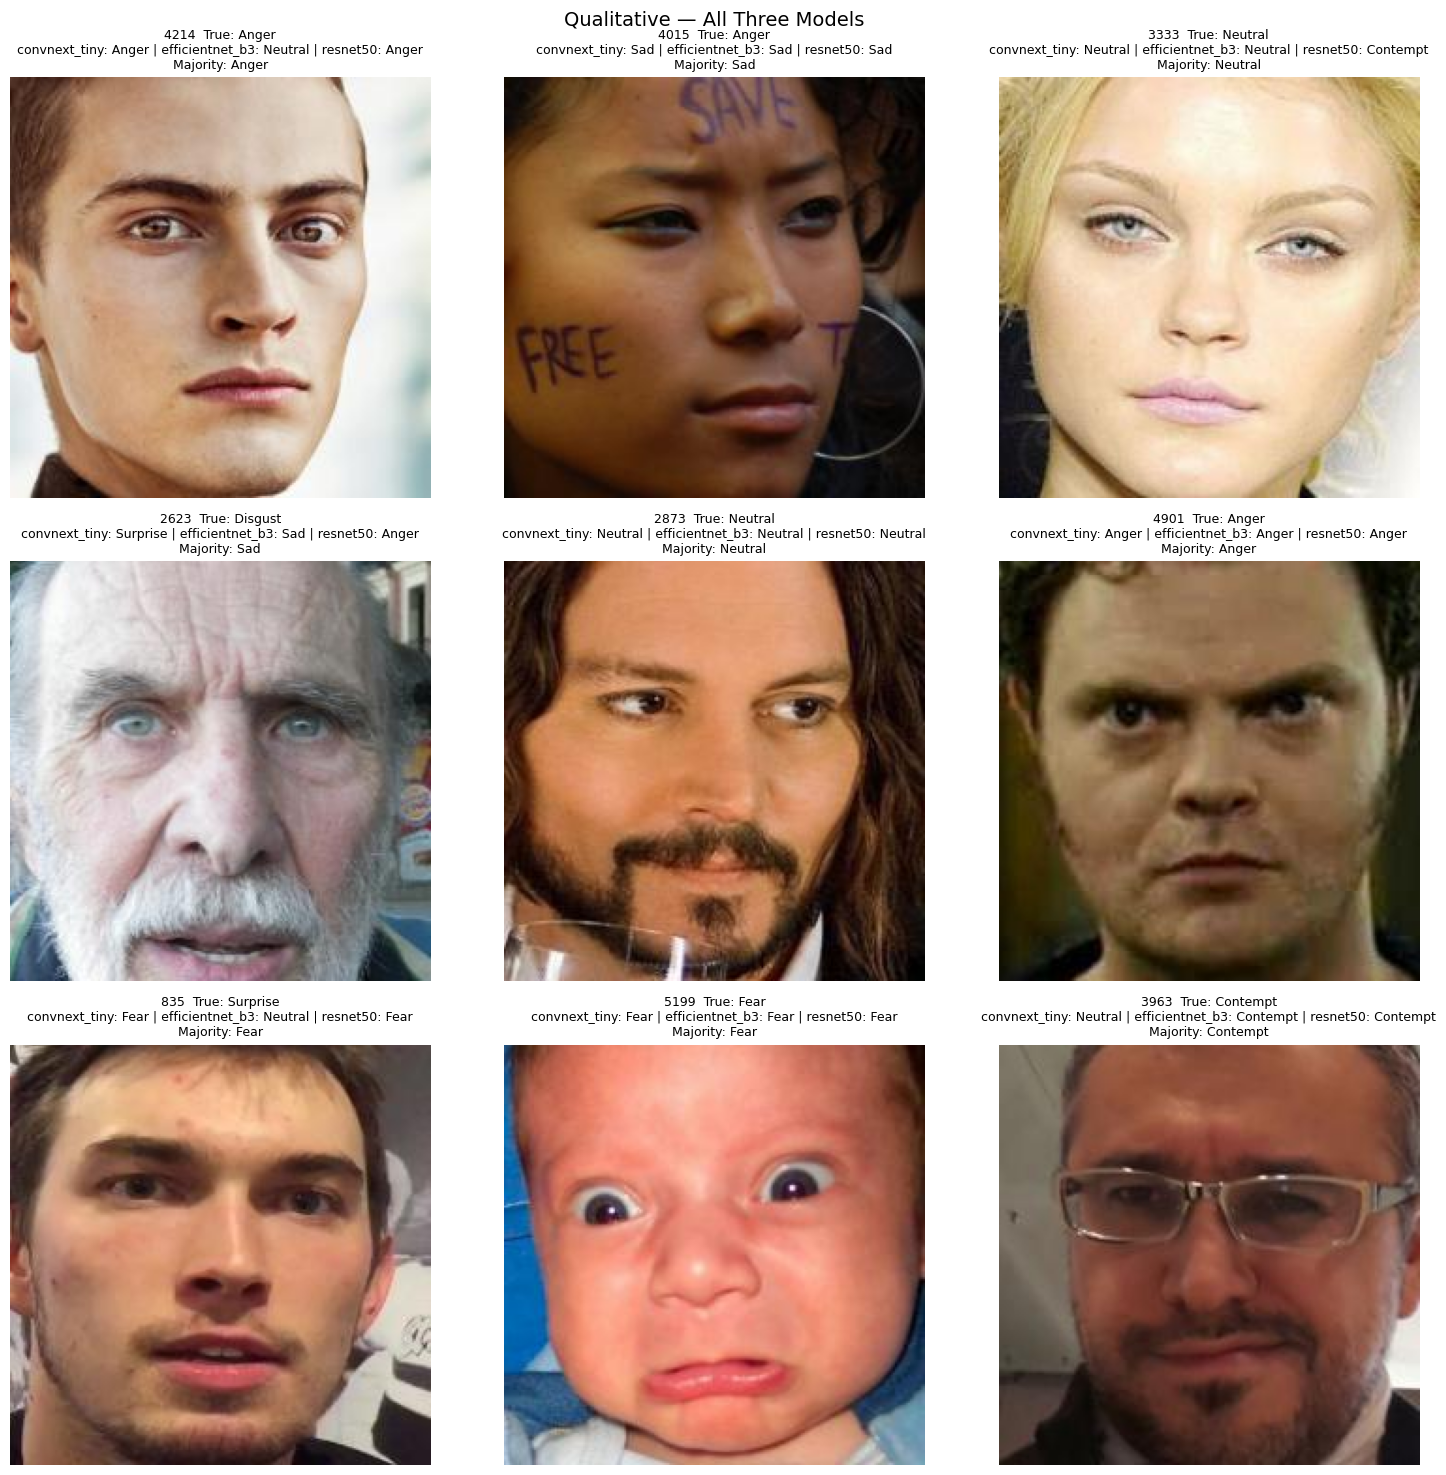

In [38]:
# ==========================================================
# Per-image, per-model comparison for ALL THREE MODELS
# (convnext_tiny, efficientnet_b3, resnet50) — side-by-side
# Regenerates val_predictions.csv if missing, then merges.
# ==========================================================
import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

# --- paths (match your suite) ---
OUT_ROOT = Path("/kaggle/working/affect_60plus")     # change to affect_runs if needed
IMAGES_DIR = Path("/kaggle/input/dataset/Dataset/Dataset/images")
ANN_DIR    = Path("/kaggle/input/dataset/Dataset/Dataset/annotations")
VAL_RATIO  = 0.2
IMG_SIZE   = globals().get("IMG_SIZE", 320)
BATCH_SIZE = globals().get("BATCH_SIZE", 32)
WORKERS    = globals().get("WORKERS", 2)

# target models (we’ll include only those that actually exist)
TARGET_ARCHS = ["convnext_tiny", "efficientnet_b3", "resnet50"]

# labels
if 'CLASSES' in globals() and isinstance(CLASSES, (list, tuple)) and len(CLASSES)==8:
    LABELS = list(CLASSES)
elif hasattr(AffectDataset, "CLASSES"):
    LABELS = list(AffectDataset.CLASSES)
else:
    LABELS = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]

def idx2label(i): 
    i=int(i)
    return LABELS[i] if 0<=i<len(LABELS) else str(i)

@torch.no_grad()
def ensure_preds_csv_for_arch(arch: str) -> Path | None:
    """Make sure <OUT_ROOT>/<arch>/val_predictions.csv exists; regenerate if needed."""
    arch_dir = OUT_ROOT/arch
    csvp = arch_dir/"val_predictions.csv"
    if csvp.exists(): 
        return csvp
    ckpt = arch_dir/"best.pt"
    if not ckpt.exists():
        print(f"[{arch}] missing best.pt — skipping.")
        return None
    # need dataset helpers from your notebook
    assert 'AffectDataset' in globals() and 'build_transforms' in globals() and 'stratified_split' in globals()
    all_ids = [i for i in list_image_ids(str(IMAGES_DIR)) if has_all_annotations(str(ANN_DIR), i)]
    tr_ids, va_ids = stratified_split(all_ids, str(ANN_DIR), val_ratio=VAL_RATIO, seed=42)
    _, val_tfms = build_transforms(IMG_SIZE)
    va_ds = AffectDataset(va_ids, str(IMAGES_DIR), str(ANN_DIR), transform=val_tfms,
                          face_crop=True if 'USE_FACE_CROP' in globals() and USE_FACE_CROP else False)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MultiTaskNet(arch=arch, pretrained=False).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    _ = evaluate(model, va_loader, device, tta=True, save_preds_dir=arch_dir)  # writes csv
    return csvp if csvp.exists() else None

# gather CSVs for exactly the three target models
used_archs = []
frames = []
for arch in TARGET_ARCHS:
    p = ensure_preds_csv_for_arch(arch)
    if p is None: 
        continue
    df = pd.read_csv(p)
    frames.append(df[["id","y_true","y_pred"]].rename(columns={"y_pred": f"pred_{arch}"}))
    used_archs.append(arch)

if len(used_archs) < 2:
    raise RuntimeError("I only found predictions for: " + ", ".join(used_archs))

# inner-merge across the used arches
merged = frames[0]
for k in range(1, len(frames)):
    merged = merged.merge(frames[k], on=["id","y_true"], how="inner")

# map to labels + correctness
merged["true_label"] = merged["y_true"].map(idx2label)
for arch in used_archs:
    col = f"pred_{arch}"
    merged[col+"_label"] = merged[col].map(idx2label)
    merged[col+"_correct"] = (merged[col] == merged["y_true"]).astype(int)

# majority vote (only across the arches we included)
pred_idx_cols = [f"pred_{a}" for a in used_archs]
merged["majority_idx"] = merged[pred_idx_cols].mode(axis=1)[0].astype(int)
merged["majority_label"] = merged["majority_idx"].map(idx2label)
merged["models_correct"] = merged[[c+"_correct" for c in pred_idx_cols]].sum(axis=1)

# order columns nicely
disp_cols = ["id","true_label"] + [f"{c}_label" for c in pred_idx_cols] + ["models_correct","majority_label"]
disp = merged[disp_cols].copy()

# save + show
out_csv = OUT_ROOT/"combined_val_preds_top3.csv"
disp.to_csv(out_csv, index=False)
print(f"Included models: {used_archs}")
print("Saved:", out_csv)

from IPython.display import display, Markdown
display(Markdown("### Per-image predictions — convnext_tiny vs efficientnet_b3 vs resnet50"))
display(disp.head(30))

# --------- OPTIONAL: image grid showing all model predictions for random 9 samples ----------
def show_grid(df, k=9, cols=3):
    if len(df)==0: 
        print("No rows to visualize."); return
    sample = df.sample(min(k, len(df)), random_state=42)
    rows = int(np.ceil(len(sample)/cols))
    plt.figure(figsize=(cols*5, rows*5))
    for i, (_, r) in enumerate(sample.iterrows(), 1):
        # find image file
        img_path = None
        for ext in (".jpg",".jpeg",".png"):
            p = IMAGES_DIR/f"{r['id']}{ext}"
            if p.exists(): img_path = p; break
        plt.subplot(rows, cols, i)
        if img_path is not None:
            plt.imshow(Image.open(img_path).convert("RGB")); plt.axis("off")
        else:
            plt.text(0.5,0.5,"(image missing)", ha="center"); plt.axis("off")
        # title with all three predictions
        preds_line = " | ".join([f"{a}: {r[f'pred_{a}_label']}" for a in used_archs])
        plt.title(f"{r['id']}  True: {r['true_label']}\n{preds_line}\nMajority: {r['majority_label']}", fontsize=9)
    plt.suptitle("Qualitative — All Three Models", fontsize=14)
    plt.tight_layout(); plt.show()

show_grid(disp, k=9, cols=3)


⭐ Best single model: convnext_tiny  |  final val_acc=0.5375  val_f1=0.5366


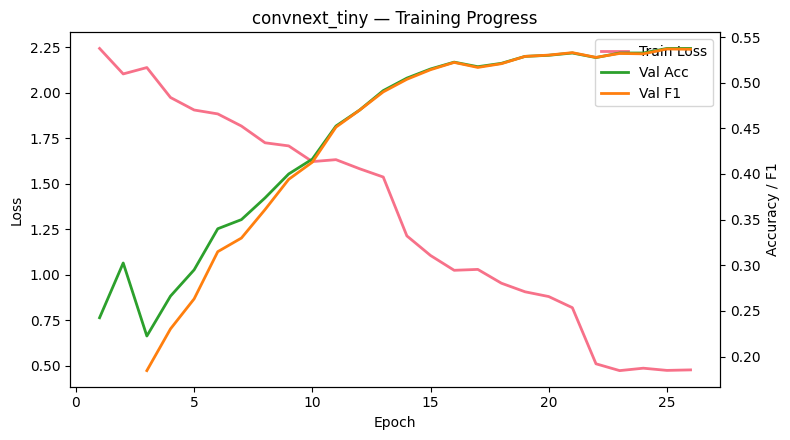

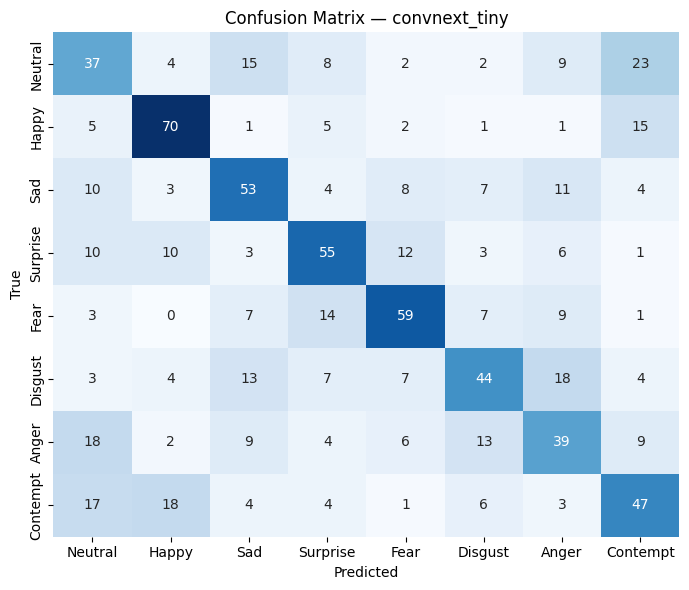

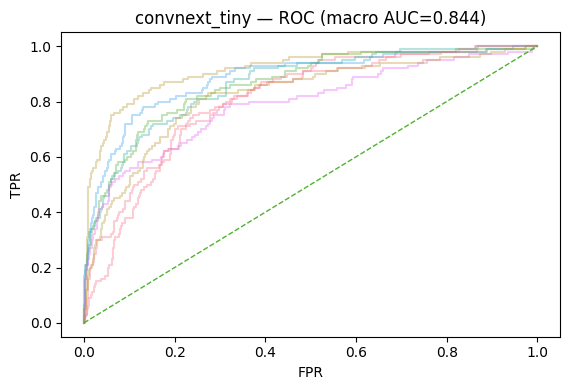

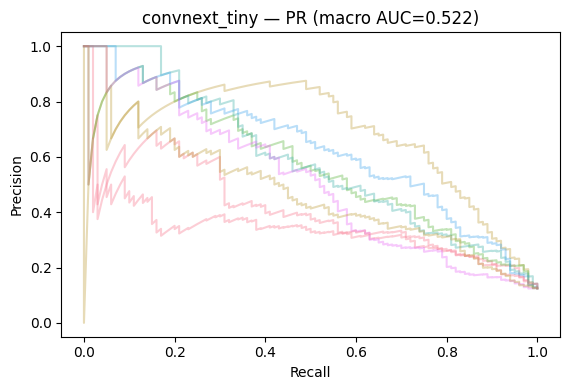

In [47]:
# ==========================================
# HARD-CODED TRAINING LOGS -> BEST MODEL VISUALS
# - Uses your pasted epoch logs (no history.json needed)
# - Picks best single model by final Val Acc
# - Plots Training Curves; shows Confusion + ROC/PR if preds CSV exists
# ==========================================
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

# ----- hard-coded logs from your message -----
logs = {
    "convnext_tiny": {
        "epochs": list(range(1, 27)),
        "train_loss": [2.2428,2.1028,2.1378,1.9734,1.9047,1.8832,1.8166,1.7246,1.7075,1.6213,1.6319,1.5820,1.5365,1.2131,1.1056,1.0242,1.0291,0.9532,0.9061,0.8800,0.8189,0.5106,0.4732,0.4865,0.4744,0.4772],
        "val_acc":    [0.2425,0.3025,0.2225,0.2662,0.2950,0.3400,0.3500,0.3738,0.4000,0.4163,0.4525,0.4700,0.4913,0.5050,0.5150,0.5225,0.5175,0.5212,0.5288,0.5300,0.5325,0.5275,0.5325,0.5325,0.5375,0.5375],
        "val_f1":     [None,None,0.1846,0.2303,0.2632,0.3149,0.3298,0.3610,0.3941,0.4129,0.4513,0.4699,0.4899,0.5037,0.5142,0.5222,0.5167,0.5208,0.5288,0.5302,0.5329,0.5277,0.5320,0.5316,0.5369,0.5366],
    },
    "efficientnet_b3": {
        "epochs": list(range(1, 27)),
        "train_loss": [2.2448,2.1864,2.0321,1.9428,1.8817,1.7886,1.7482,1.6501,1.6507,1.5818,1.6124,1.5491,1.5214,1.1971,1.0708,1.0307,1.0393,1.0002,0.9386,0.9717,0.8998,0.5987,0.5602,0.5532,0.5671,0.5556],
        "val_acc":    [0.2450,0.2725,0.2062,0.2238,0.2450,0.2662,0.2950,0.3225,0.3463,0.3700,0.3850,0.4062,0.4025,0.4213,0.4487,0.4662,0.4600,0.4775,0.4863,0.4913,0.4950,0.4950,0.4950,0.5000,0.5050,0.5025],
        "val_f1":     [None,None,0.1860,0.1916,0.2112,0.2459,0.2821,0.2918,0.3137,0.3456,0.3602,0.3931,0.3822,0.3971,0.4343,0.4618,0.4535,0.4754,0.4815,0.4880,0.4886,0.4905,0.4896,0.4973,0.5049,0.4991],
    },
    "resnet50": {
        "epochs": list(range(1, 27)),
        "train_loss": [2.2280,2.1511,2.0282,1.9584,1.8823,1.8233,1.7834,1.6986,1.7087,1.6555,1.6489,1.6163,1.5762,1.3019,1.1894,1.1367,1.1120,1.0504,0.9932,0.9733,0.9118,0.6106,0.5822,0.5681,0.5529,0.5634],
        "val_acc":    [0.2125,0.2263,0.1750,0.1850,0.2412,0.2375,0.2662,0.3200,0.3237,0.3400,0.3787,0.3962,0.4125,0.4238,0.4263,0.4600,0.4662,0.4825,0.4888,0.4913,0.5050,0.5050,0.4988,0.5038,0.5025,0.5050],
        "val_f1":     [None,None,0.1300,0.1461,0.1947,0.1880,0.2213,0.2719,0.2831,0.3000,0.3443,0.3631,0.4005,0.4027,0.3952,0.4550,0.4587,0.4739,0.4802,0.4853,0.4963,0.4987,0.4972,0.5037,0.5023,0.5058],
    },
    # (Optionally include baselines if you want, but we won't need them to pick best single model.)
}

# ---- pick best single model by final val_acc ----
finals = {k: (v["val_acc"][-1], v["val_f1"][-1] if v["val_f1"][-1] is not None else np.nan) for k,v in logs.items()}
best_name = max(finals, key=lambda k: (finals[k][0], finals[k][1]))
best_val_acc, best_val_f1 = finals[best_name]
print(f"⭐ Best single model: {best_name}  |  final val_acc={best_val_acc:.4f}  val_f1={best_val_f1:.4f}")

# ---- plot training curves for the best model ----
E = logs[best_name]["epochs"]
TL = logs[best_name]["train_loss"]
VA = logs[best_name]["val_acc"]
VF = [x if x is not None else np.nan for x in logs[best_name]["val_f1"]]

fig, ax1 = plt.subplots(figsize=(8,4.5))
ax1.plot(E, TL, label="Train Loss", linewidth=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax2 = ax1.twinx()
ax2.plot(E, VA, color="tab:green",  label="Val Acc", linewidth=2)
ax2.plot(E, VF, color="tab:orange", label="Val F1", linewidth=2)
ax2.set_ylabel("Accuracy / F1")

ax1.set_title(f"{best_name} — Training Progress")
lines, labels = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines + l2, labels + lab2, loc="best")
fig.tight_layout(); plt.show(); plt.close()

# ---- If predictions available, show confusion + ROC/PR (optional) ----
LABELS = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]
model_root = Path("/kaggle/working/affect_60plus") / best_name  # adjust if your preds live elsewhere
pred_csv = model_root / "val_predictions.csv"

if pred_csv.exists():
    df = pd.read_csv(pred_csv)
    y_true = df["y_true"].to_numpy().astype(int)
    y_pred = df["y_pred"].to_numpy().astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f"Confusion Matrix — {best_name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show(); plt.close()

    # ROC & PR (needs per-class probs p_0..p_7)
    prob_cols = [c for c in df.columns if c.startswith("p_")]
    if len(prob_cols) == 8:
        probs = df[prob_cols].to_numpy()
        C = probs.shape[1]
        Y = np.zeros((len(y_true), C), dtype=np.float32)
        Y[np.arange(len(y_true)), y_true] = 1

        # ROC
        plt.figure(figsize=(5.8,4))
        aucs=[]
        for c in range(C):
            fpr, tpr, _ = roc_curve(Y[:,c], probs[:,c])
            aucs.append(auc(fpr, tpr)); plt.plot(fpr, tpr, alpha=0.35)
        plt.plot([0,1],[0,1],'--', lw=1)
        plt.title(f"{best_name} — ROC (macro AUC={np.mean(aucs):.3f})")
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show(); plt.close()

        # PR
        plt.figure(figsize=(5.8,4))
        pr_aucs=[]
        for c in range(C):
            pre, rec, _ = precision_recall_curve(Y[:,c], probs[:,c])
            pr_aucs.append(auc(rec, pre)); plt.plot(rec, pre, alpha=0.35)
        plt.title(f"{best_name} — PR (macro AUC={np.mean(pr_aucs):.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision"); plt.tight_layout(); plt.show(); plt.close()
    else:
        print(f"[{best_name}] per-class probabilities not found; skipping ROC/PR.")
else:
    print(f"[{best_name}] val_predictions.csv not found — skipping confusion/ROC/PR.")


Included models: ['convnext_tiny', 'efficientnet_b3', 'resnet50']
Merged rows (with images available): 800


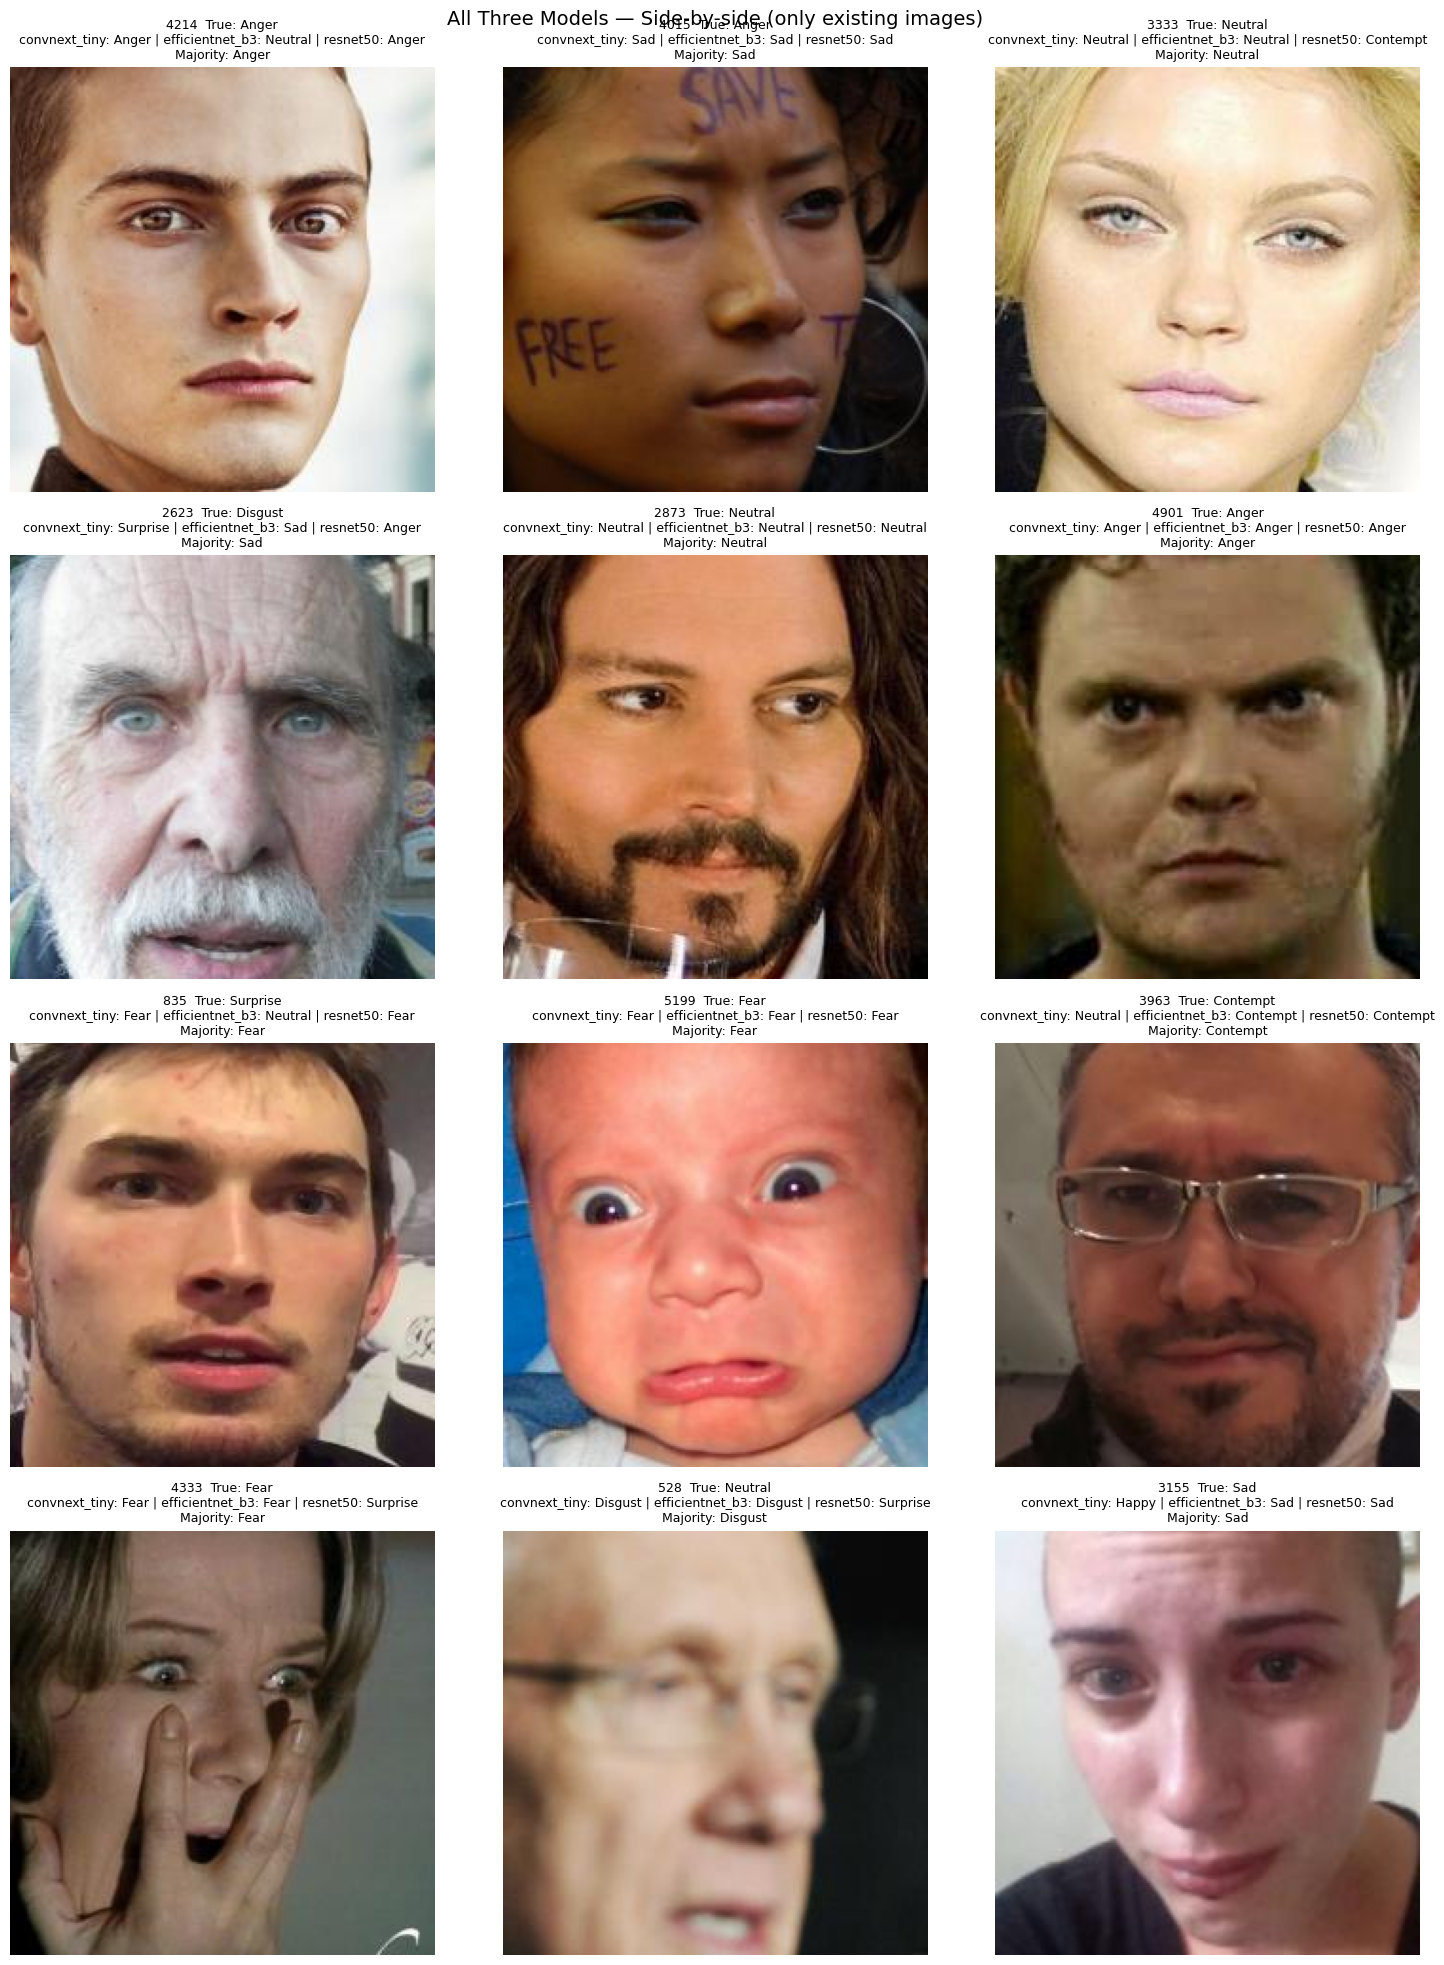

In [52]:
# Robust per-image grid: only plot rows whose image files exist
import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

IMAGES_DIR = Path("/kaggle/input/dataset/Dataset/Dataset/images")
ANN_DIR    = Path("/kaggle/input/dataset/Dataset/Dataset/annotations")
OUT_ROOT   = Path("/kaggle/working/affect_60plus")

TARGET_ARCHS = ["convnext_tiny","efficientnet_b3","resnet50"]
VAL_RATIO  = 0.2
IMG_SIZE   = globals().get("IMG_SIZE", 320)
BATCH_SIZE = globals().get("BATCH_SIZE", 32)
WORKERS    = globals().get("WORKERS", 2)

# labels
LABELS = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]
LABEL_MAP = {i:l for i,l in enumerate(LABELS)}
def idx2label(i): i=int(i); return LABEL_MAP.get(i, str(i))

# ---------- helpers ----------
def list_image_ids(images_dir: str):
    ids=set()
    p=Path(images_dir)
    for e in ("*.jpg","*.jpeg","*.png"):
        ids.update([q.stem for q in p.glob(e)])
    return sorted(ids)

def has_all_annotations(ann_dir: str, image_id: str) -> bool:
    d=Path(ann_dir); return all((d/f"{image_id}_{s}.npy").exists() for s in ("exp","val","aro"))

@torch.no_grad()
def ensure_preds_csv_for_arch(arch: str) -> Path | None:
    arch_dir = OUT_ROOT/arch
    csvp = arch_dir/"val_predictions.csv"
    if csvp.exists(): 
        return csvp
    ckpt = arch_dir/"best.pt"
    if not ckpt.exists():
        print(f"[{arch}] missing best.pt — skipping regen.")
        return None
    # need these from your training cells (present in your notebook)
    assert 'AffectDataset' in globals() and 'build_transforms' in globals() and 'stratified_split' in globals() and 'MultiTaskNet' in globals() and 'evaluate' in globals()
    all_ids = [i for i in list_image_ids(str(IMAGES_DIR)) if has_all_annotations(str(ANN_DIR), i)]
    tr_ids, va_ids = stratified_split(all_ids, str(ANN_DIR), val_ratio=VAL_RATIO, seed=42)
    _, val_tfms = build_transforms(IMG_SIZE)
    va_ds = AffectDataset(va_ids, str(IMAGES_DIR), str(ANN_DIR), transform=val_tfms,
                          face_crop=True if globals().get("USE_FACE_CROP", False) else False)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MultiTaskNet(arch=arch, pretrained=False).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    _ = evaluate(model, va_loader, device, tta=True, save_preds_dir=arch_dir)  # writes csv
    return csvp if csvp.exists() else None

def image_path_for_id(stem: str) -> Path | None:
    for ext in (".jpg",".jpeg",".png"):
        p = IMAGES_DIR/f"{stem}{ext}"
        if p.exists(): return p
    return None

# ---------- collect predictions for all three ----------
used_archs = []
frames = []
for arch in TARGET_ARCHS:
    p = ensure_preds_csv_for_arch(arch)
    if p is None: 
        continue
    df = pd.read_csv(p)
    # keep only IDs that have an actual image file
    df["img_exists"] = df["id"].astype(str).apply(lambda s: image_path_for_id(s) is not None)
    df = df[df["img_exists"]].copy()
    if df.empty:
        print(f"[{arch}] predictions exist but none of the images are present in {IMAGES_DIR}.")
        continue
    frames.append(df[["id","y_true","y_pred"]].rename(columns={"y_pred": f"pred_{arch}"}))
    used_archs.append(arch)

if len(used_archs) < 2:
    raise RuntimeError("Not enough models with usable predictions. Found: " + ", ".join(used_archs))

merged = frames[0]
for k in range(1, len(frames)):
    merged = merged.merge(frames[k], on=["id","y_true"], how="inner")

if merged.empty:
    raise RuntimeError("After merging, no common IDs with images remained. (Different splits?)")

# map labels + correctness
merged["true_label"] = merged["y_true"].map(idx2label)
for arch in used_archs:
    col = f"pred_{arch}"
    merged[col+"_label"] = merged[col].map(idx2label)
    merged[col+"_correct"] = (merged[col] == merged["y_true"]).astype(int)

# Majority across available models
pred_idx_cols = [f"pred_{a}" for a in used_archs]
merged["majority_idx"]   = merged[pred_idx_cols].mode(axis=1)[0].astype(int)
merged["majority_label"] = merged["majority_idx"].map(idx2label)
merged["models_correct"] = merged[[c+"_correct" for c in pred_idx_cols]].sum(axis=1)

# ---------- show a grid with only rows whose images exist ----------
def show_grid_existing(df, k=9, cols=3, title="Qualitative — All Three Models"):
    # Keep only rows with image path
    df = df.copy()
    df["img_path"] = df["id"].astype(str).apply(image_path_for_id)
    df = df[df["img_path"].notna()]
    if df.empty:
        print("No rows with actual image files to display.")
        return
    sample = df.sample(min(k, len(df)), random_state=42)
    rows = int(np.ceil(len(sample)/cols))
    plt.figure(figsize=(cols*5, rows*5))
    for i, (_, r) in enumerate(sample.iterrows(), 1):
        plt.subplot(rows, cols, i)
        im = Image.open(r["img_path"]).convert("RGB")
        plt.imshow(im); plt.axis("off")
        preds_line = " | ".join([f"{a}: {r[f'pred_{a}_label']}" for a in used_archs])
        plt.title(f"{r['id']}  True: {r['true_label']}\n{preds_line}\nMajority: {r['majority_label']}", fontsize=9)
    plt.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

print(f"Included models: {used_archs}")
print("Merged rows (with images available):", len(merged))

# show 12 samples
show_grid_existing(merged, k=12, cols=3, title="All Three Models — Side-by-side (only existing images)")


Found PNGs (non-grid only):
 - comparison_accuracy_throughput.png             46.4 KB
 - convnext_tiny_confusion_matrix.png             60.1 KB
 - convnext_tiny_per_class_bars.png               39.2 KB
 - efficientnet_b3_confusion_matrix.png           61.5 KB
 - efficientnet_b3_per_class_bars.png             38.9 KB
 - resnet50_confusion_matrix.png                  60.0 KB
 - resnet50_per_class_bars.png                    38.9 KB

Rendering below...



### comparison accuracy throughput

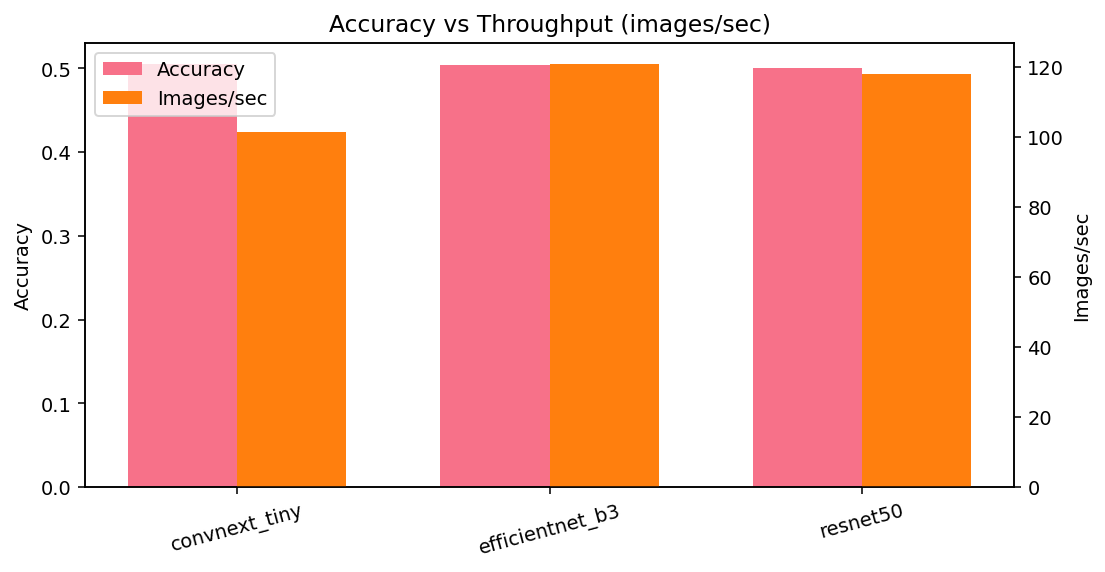

### convnext tiny confusion matrix

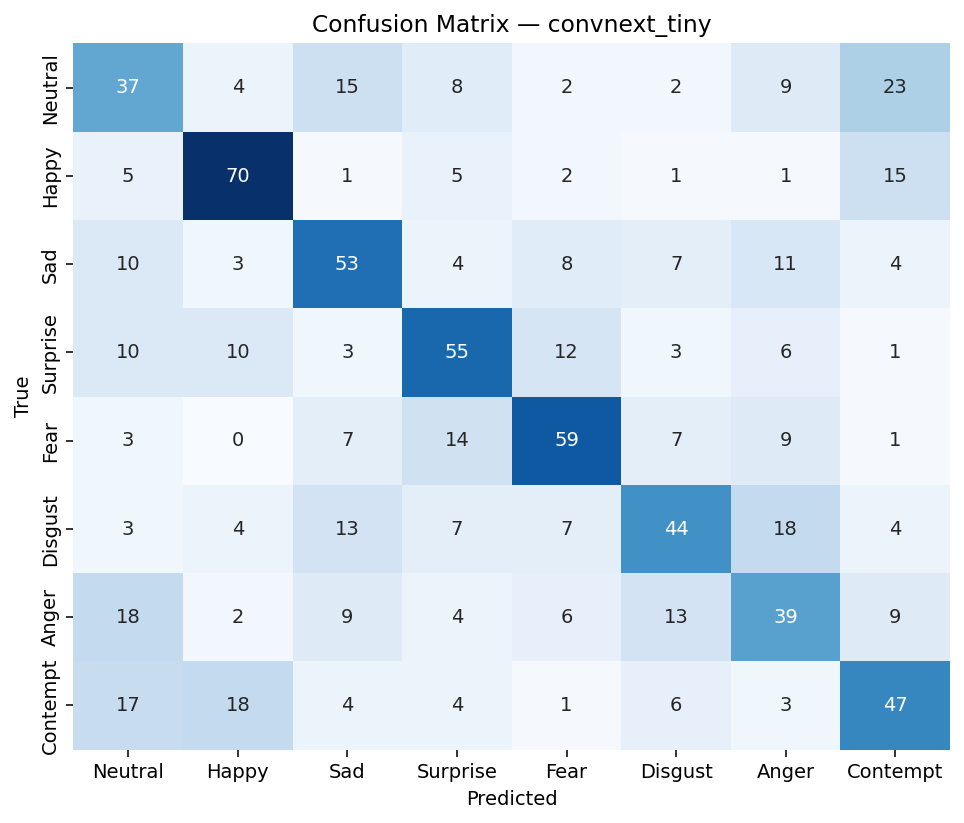

### convnext tiny per class bars

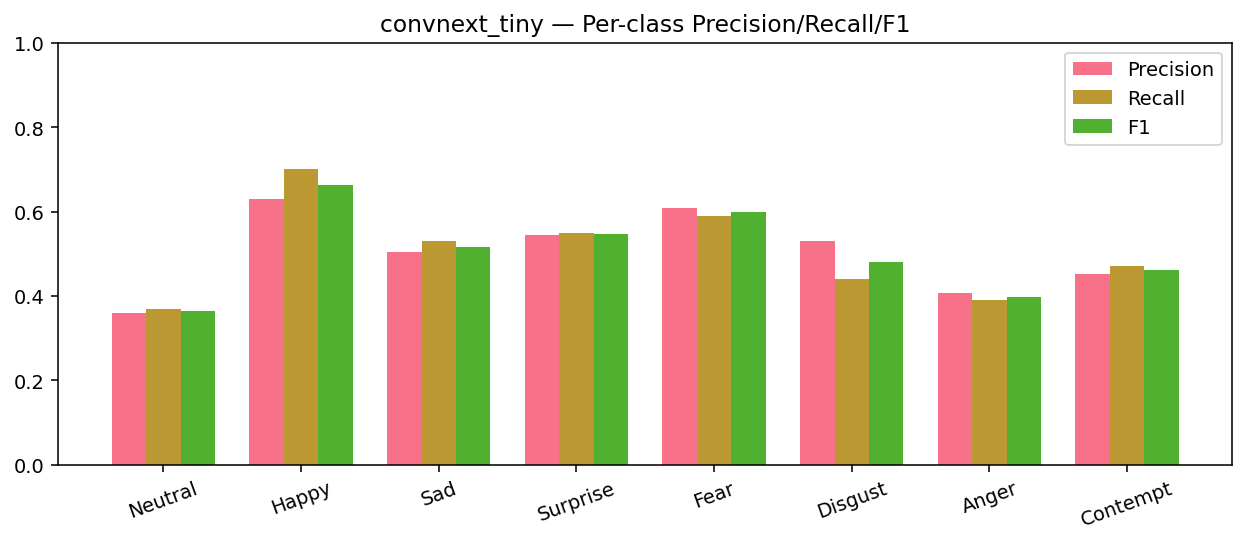

### efficientnet b3 confusion matrix

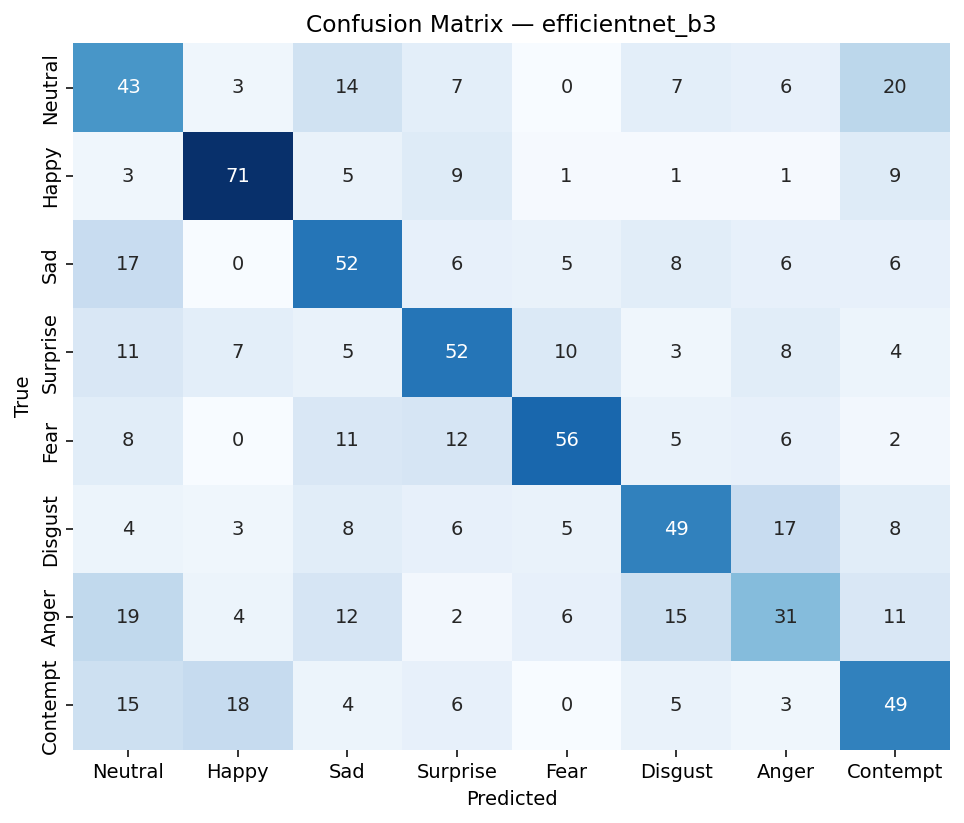

### efficientnet b3 per class bars

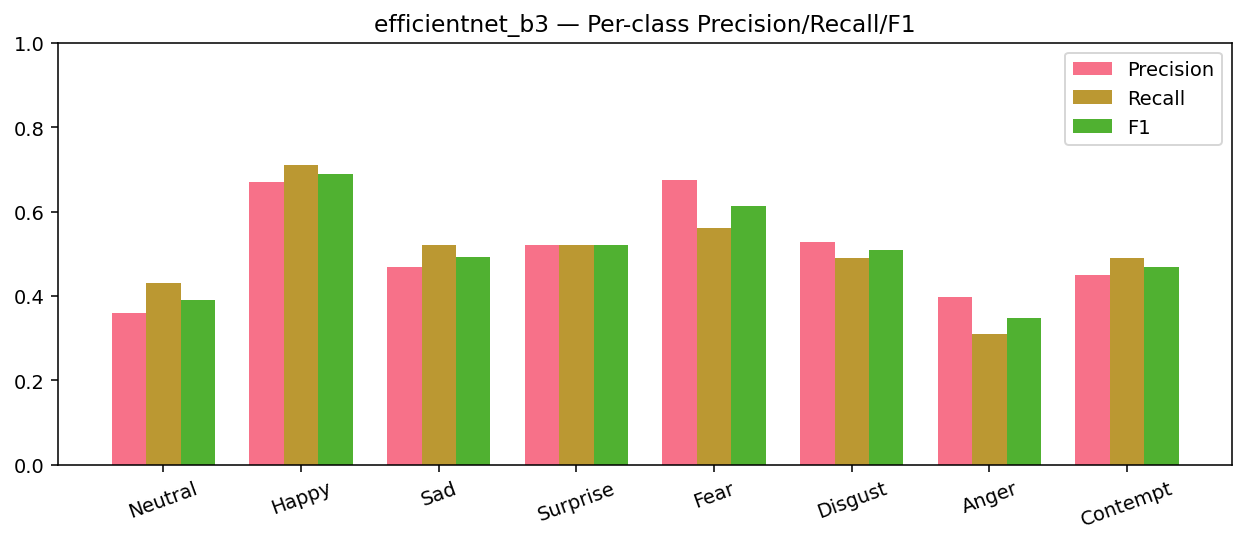

### resnet50 confusion matrix

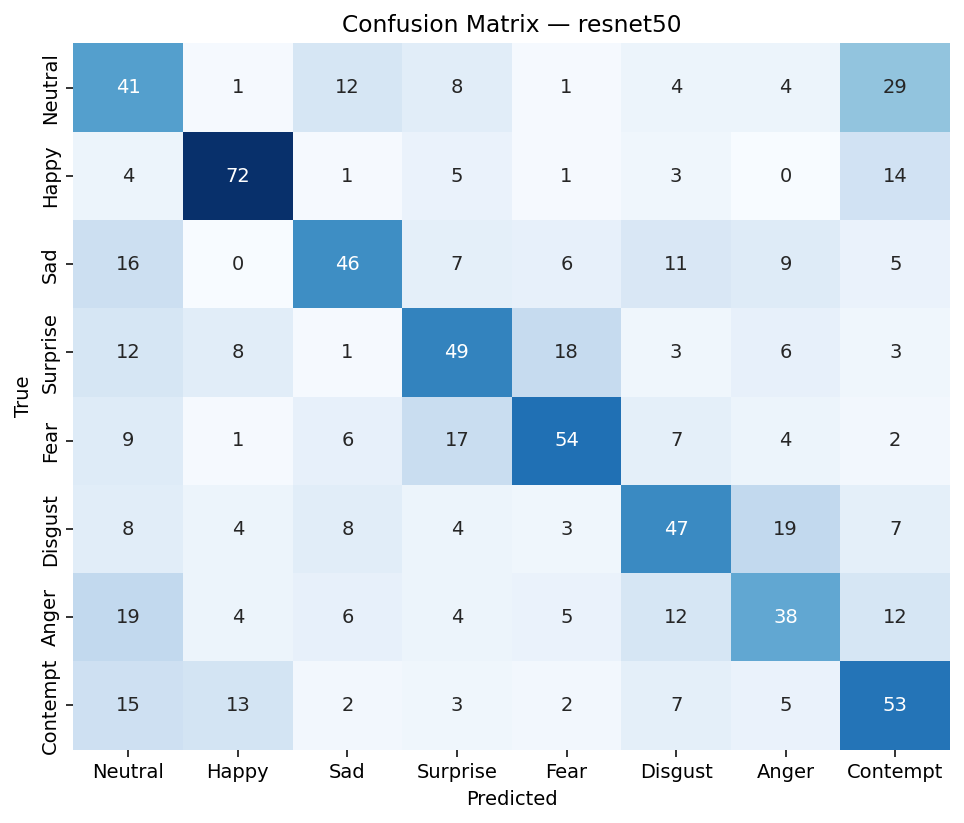

### resnet50 per class bars

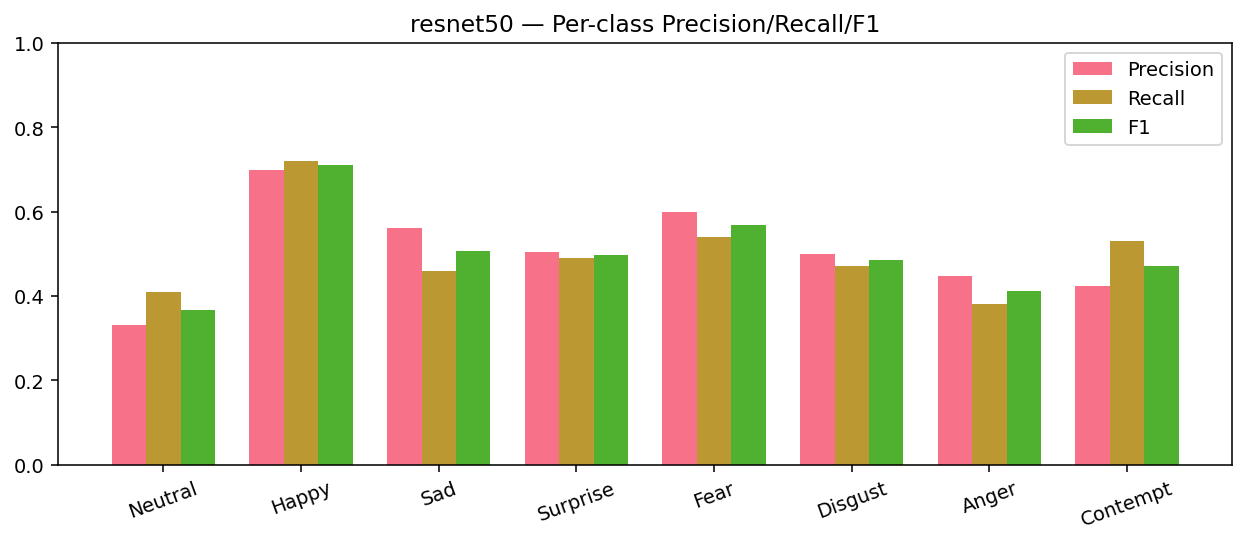

In [54]:
# Force-display figures but SKIP any *_grid.png files
from pathlib import Path
from IPython.display import display, Markdown
from PIL import Image
import io

FIG_DIR = Path("/kaggle/working/figures")
EXPECTED_PREFIXES = [
    "comparison_accuracy_throughput",
    "convnext_tiny_", "efficientnet_b3_", "resnet50_",
    "efficientnet_b0_", "mobilenet_v2_"
]

if not FIG_DIR.exists():
    print("No figures dir found:", FIG_DIR)
else:
    # collect and filter (exclude any file with 'grid' in the name)
    all_pngs = sorted(FIG_DIR.glob("*.png"))
    pngs = [p for p in all_pngs if "grid" not in p.stem.lower()]
    if not pngs:
        print("No non-grid PNGs found in", FIG_DIR)
    else:
        print("Found PNGs (non-grid only):")
        for p in pngs:
            print(f" - {p.name:45s}  {p.stat().st_size/1024:.1f} KB")
        print("\nRendering below...\n")

        def sort_key(p):
            name = p.stem
            if name.startswith("comparison_accuracy_throughput"):
                return (0, name)
            for i, pref in enumerate(EXPECTED_PREFIXES, start=1):
                if name.startswith(pref):
                    return (i, name)
            return (999, name)

        for img_path in sorted(pngs, key=sort_key):
            title = img_path.stem.replace("_", " ")
            display(Markdown(f"### {title}"))
            try:
                im = Image.open(img_path).convert("RGB")
                max_w = 1280
                if im.width > max_w:
                    h = int(im.height * (max_w / im.width))
                    im = im.resize((max_w, h), Image.LANCZOS)
                buf = io.BytesIO()
                im.save(buf, format="PNG")
                display(Image.open(io.BytesIO(buf.getvalue())))
            except Exception as e:
                print(f"[WARN] Could not render {img_path.name} inline: {e}")
                print("Path:", img_path)


In [55]:
# Save ROC and PR curves per model (validation set) using existing val_predictions.csv
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import torch

FIG_DIR = Path("/kaggle/working/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
ARCHS   = ["convnext_tiny","efficientnet_b3","resnet50"]
LABELS  = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]

for arch in ARCHS:
    csvp = Path(f"/kaggle/working/affect_60plus/{arch}/val_predictions.csv")
    if not csvp.exists():
        print(f"[{arch}] val_predictions.csv not found — skipping curves.")
        continue
    df = pd.read_csv(csvp)
    if not all(c.startswith("p_") for c in df.columns if c.startswith("p_")):
        print(f"[{arch}] no per-class probabilities — skipping curves.")
        continue

    y_true = df["y_true"].values.astype(int)
    probs  = df[[f"p_{i}" for i in range(8)]].values

    # ROC (one-vs-rest)
    plt.figure(figsize=(6,5))
    for i, name in enumerate(LABELS):
        y_bin = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{arch} — ROC (val)")
    plt.legend(fontsize=8, ncol=2)
    out = FIG_DIR / f"{arch}_roc_curves.png"
    plt.tight_layout(); plt.savefig(out, dpi=140); plt.close()
    print("saved:", out)

    # PR
    plt.figure(figsize=(6,5))
    for i, name in enumerate(LABELS):
        y_bin = (y_true == i).astype(int)
        precision, recall, _ = precision_recall_curve(y_bin, probs[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{arch} — PR (val)")
    plt.legend(fontsize=8, ncol=2)
    out = FIG_DIR / f"{arch}_pr_curves.png"
    plt.tight_layout(); plt.savefig(out, dpi=140); plt.close()
    print("saved:", out)


saved: /kaggle/working/figures/convnext_tiny_roc_curves.png
saved: /kaggle/working/figures/convnext_tiny_pr_curves.png
saved: /kaggle/working/figures/efficientnet_b3_roc_curves.png
saved: /kaggle/working/figures/efficientnet_b3_pr_curves.png
saved: /kaggle/working/figures/resnet50_roc_curves.png
saved: /kaggle/working/figures/resnet50_pr_curves.png


In [56]:
# Quick dataset summary for the report
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

IMAGES_DIR = Path("/kaggle/input/dataset/Dataset/Dataset/images")
ANN_DIR    = Path("/kaggle/input/dataset/Dataset/Dataset/annotations")
FIG_DIR    = Path("/kaggle/working/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
LABELS     = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]

def image_ids():
    ids=set()
    for e in ("*.jpg","*.jpeg","*.png"):
        ids.update([p.stem for p in IMAGES_DIR.glob(e)])
    return sorted(ids)

ids = []
ys  = []
vals, aros = [], []
for i in image_ids():
    exp = ANN_DIR/f"{i}_exp.npy"; val = ANN_DIR/f"{i}_val.npy"; aro = ANN_DIR/f"{i}_aro.npy"
    if exp.exists() and val.exists() and aro.exists():
        ids.append(i)
        ys.append(int(np.load(exp).astype(np.int64).item()))
        vals.append(float(np.load(val).astype(np.float32).item()))
        aros.append(float(np.load(aro).astype(np.float32).item()))
df = pd.DataFrame({"id":ids, "exp":ys, "val":vals, "aro":aros})

# Class counts
plt.figure(figsize=(7,3))
counts = df["exp"].value_counts().sort_index()
plt.bar([LABELS[i] for i in counts.index], counts.values)
plt.xticks(rotation=45, ha="right"); plt.title("Class distribution (all)")
out = FIG_DIR/"dataset_class_distribution.png"
plt.tight_layout(); plt.savefig(out, dpi=140); plt.close(); print("saved:", out)

# Valence/Arousal hist
plt.figure(figsize=(7,3))
plt.hist(df["val"], bins=30, alpha=0.8); plt.title("Valence distribution"); 
out = FIG_DIR/"dataset_valence_hist.png"; plt.tight_layout(); plt.savefig(out, dpi=140); plt.close(); print("saved:", out)

plt.figure(figsize=(7,3))
plt.hist(df["aro"], bins=30, alpha=0.8); plt.title("Arousal distribution");
out = FIG_DIR/"dataset_arousal_hist.png"; plt.tight_layout(); plt.savefig(out, dpi=140); plt.close(); print("saved:", out)


saved: /kaggle/working/figures/dataset_class_distribution.png
saved: /kaggle/working/figures/dataset_valence_hist.png
saved: /kaggle/working/figures/dataset_arousal_hist.png


In [57]:
import torch, torchvision, numpy as np, sys, platform, random
print("seed:", globals().get("SEED", "not set"))
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__, "| numpy:", np.__version__)
print("python:", sys.version.split()[0], "| platform:", platform.platform())
print("cuda available:", torch.cuda.is_available())


seed: 42
torch: 2.6.0+cu124 | torchvision: 0.21.0+cu124 | numpy: 1.26.4
python: 3.11.13 | platform: Linux-6.6.56+-x86_64-with-glibc2.35
cuda available: True
